In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
modul_path = "/work/scheibe5/bacteriophate_t7"
if modul_path not in sys.path:
    sys.path.append(modul_path)
import stochastinetics
import multiprocess

In [2]:
from functools import partial

In [7]:
import numpy as np
from scipy.integrate import solve_ivp

# Event: bricht sofort bei t0 aus (g(t, y) = 0)
def g(t, y):
    return 0.0
g.terminal = True

# System: 0 * leeres_array -> leeres_array
A = np.zeros((0, 0))
def rhs(t, y):
    return A @ y

y0 = np.array([])

res = solve_ivp(rhs, (0, 100), y0, events=g)

print("Status:", res.status)  # Output: 1 (Terminal event occurred)
print("Time points:", res.t)  # Output: [0.]
print("Message:", res.message) # Output: 'A termination event occurred.'

Status: 1
Time points: [0. 0.]
Message: A termination event occurred.


### Model/Parameter Definition

In [2]:
k1 = 0.025
k2 = 0.25
k3 = 1.0
k4 = 7.5*10**(-6)
k5 = 1000
k6 = 1.99
tem0 = 1
gen0 = 0
struc0 = 0
Delta_t = 10**(-3)
delta_t = 10**(-2)
I1 = 25.0
I2 = 35.0
boundaries = np.array([I1,I2,I1,I2,I1,I2])

S = np.array([[-1,0,1,-1,0,0],[1,-1,0,0,0,0],[0,0,0,-1,1,-1]]) # order [gen,tem,struc]
S_ed = np.array([[1,0,0,1,0,0],[0,1,1,0,1,0],[0,0,0,1,0,1]],dtype=int)
c = np.array([k1,k2,k3,k4,k5,k6]) # assuming this are already the volume dependent constants...
x0 = np.array([gen0,tem0,struc0])

### Deterministic

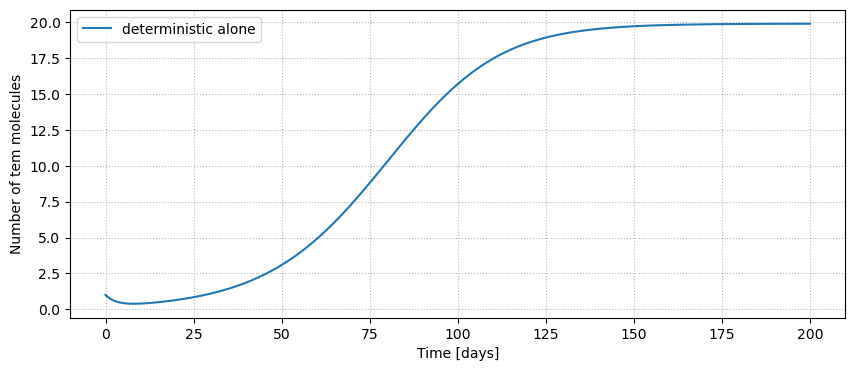

In [3]:
from scipy.integrate import solve_ivp
import numpy as np
from matplotlib import pyplot as plt

def rate_of_change(t,x,S,c):
    gen_dot = -c[0]*x[0] + c[2]*x[1] - c[3]*x[0]*x[2]
    tem_dot = c[0]*x[0]-c[1]*x[1]
    struc_dot = -c[3]*x[0]*x[2] + c[4]*x[1] -c[5]*x[2]
    return gen_dot,tem_dot,struc_dot

t_start = 0
t_end = 200
n1 = 10000
t_eval = np.linspace(t_start, t_end, n1)

bacteriophage = solve_ivp(rate_of_change,(t_start,t_end),x0,t_eval=t_eval,args=(S,c))

tem = bacteriophage.y[1]

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(bacteriophage.t, tem, label="deterministic alone")
ax1.legend()
ax1.set_xlabel("Time [days]")
ax1.set_ylabel("Number of tem molecules")
ax1.grid(True, linestyle=':', color='gray', alpha=0.6)

### SSA

In [47]:
import multiprocessing
import os
import time
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from tqdm import tqdm

# Deine Konstanten (bleiben global für das Hauptskript)
k1, k2, k3, k4, k5, k6 = 0.025, 0.25, 1.0, 7.5 * 10**-6, 1000, 1.99
tem0, gen0, struc0 = 1, 0, 0
t0, tf = 0, 200
n = 4

S = np.array([[-1, 0, 1, -1, 0, 0], [1, -1, 0, 0, 0, 0], [0, 0, 0, -1, 1, -1]])
S_ed = np.array([[1, 0, 0, 1, 0, 0], [0, 1, 1, 0, 1, 0], [0, 0, 0, 1, 0, 1]], dtype=int)
c = np.array([k1, k2, k3, k4, k5, k6])
x0 = np.array([gen0, tem0, struc0])

t_start, t_end, n1 = 0, 200, 10000


# Deterministisches System
def rate_of_change(t, x, S, c):
    gen_dot = -c[0] * x[0] + c[2] * x[1] - c[3] * x[0] * x[2]
    tem_dot = c[0] * x[0] - c[1] * x[1]
    struc_dot = -c[3] * x[0] * x[2] + c[4] * x[1] - c[5] * x[2]
    return gen_dot, tem_dot, struc_dot

def init_worker():
    np.random.seed(int(time.time() * 1000) % 2**32 + os.getpid())

def run_single_ssa(i, S=S, S_ed=S_ed, c=c, t0=t0, x0=x0, tf=tf):
    t, z = stochastinetics.SSA(S, S_ed, c, t0, x0, tf)
    return t, z


if __name__ == "__main__":
    t_eval = np.linspace(t_start, t_end, n1)
    bacteriophage = solve_ivp(
        rate_of_change, (t_start, t_end), x0, t_eval=t_eval, args=(S, c)
    )
    tem = bacteriophage.y[1]
    
    result_ssa = []
    start = time.time()
    num_cpus = len(os.sched_getaffinity(0))

    print(f"Starte Simulation auf {num_cpus} CPUs... (Gesamtanzahl: {n})", flush=True)

    with multiprocessing.Pool(processes=num_cpus, initializer=init_worker) as pool:
        for i,(t, z) in enumerate(pool.imap_unordered(run_single_ssa, range(n), chunksize=1), 1):
            result_ssa.append([t, z])
            if i % 100 == 0 or i == n:
                print(f"[PROGRESS] {i}/{n} Simulationen beendet ({i/n*100:.1f}%)", flush=True)
    end = time.time()
    print(f"Time elapsed: {end - start:.2f} seconds.")

    # 3. Auswertung & Plot
    t_range = np.arange(0, 200, 2)
    ssa_exp = stochastinetics.expectation(result_ssa, n, t_range)[:,1]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(bacteriophage.t, tem, label="deterministic")
    ax.plot(t_range, ssa_exp, label="ssa")
    ax.legend()
    ax.set_xlabel("Time [days]")
    ax.set_ylabel("Number of tem molecules")
    ax.grid(True, linestyle=":", color="gray", alpha=0.6)

    path2 = os.path.join("/home/scheibe5", "bacteriophage_model_ssa_and_deterministic.png")
    plt.savefig(path2)
    plt.show()

Starte Simulation auf 2 CPUs... (Gesamtanzahl: 4)
[PROGRESS] 1/4 Simulationen beendet (25.0%)


IndexError: list index out of range

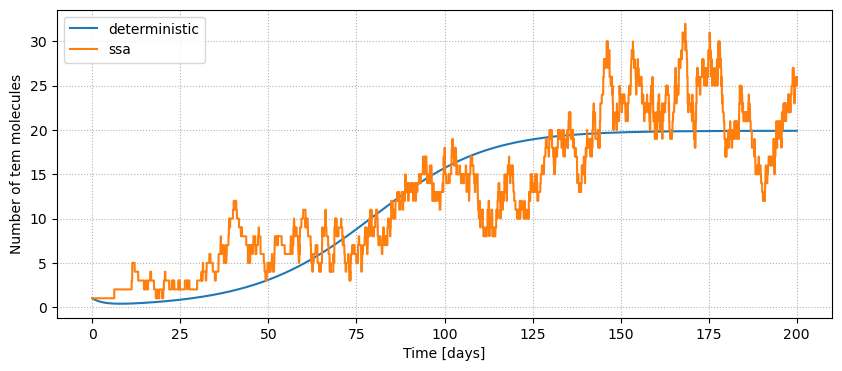

In [44]:
#t_range = np.arange(0, 200, 2)
#ssa_exp = stochastinetics.expectation(result_ssa, n, t_range)[:,1]
#ssa_traj1 = result_ssa[0][1][:,1]
i = 3

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(bacteriophage.t, tem, label="deterministic")
ax.plot(result_ssa[i][0], result_ssa[i][1][:,1], label="ssa")
ax.legend()
ax.set_xlabel("Time [days]")
ax.set_ylabel("Number of tem molecules")
ax.grid(True, linestyle=":", color="gray", alpha=0.6)

path2 = os.path.join("/home/scheibe5", "bacteriophage_model_ssa_and_deterministic.png")
plt.savefig(path2)
plt.show()

### Alfonsi 

In [11]:
# find threshold
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
from scipy.integrate import solve_ivp
modul_path = "/home/scheibe5"
if modul_path not in sys.path:
    sys.path.append(modul_path)
import stochastinetics
from tqdm import tqdm
import time
import multiprocess

k1 = 0.025
k2 = 0.25
k3 = 1.0
k4 = 7.5*10**(-6)
k5 = 1000
k6 = 1.99
tem0 = 1
gen0 = 0
struc0 = 0
Delta_t = 10**(-3)
delta_t = 10**(-2)
I1 = 25.0
I2 = 35.0
boundaries = np.array([I1,I2,I1,I2,I1,I2])

S = np.array([[-1,0,1,-1,0,0],[1,-1,0,0,0,0],[0,0,0,-1,1,-1]]) # order [gen,tem,struc]
S_ed = np.array([[1,0,0,1,0,0],[0,1,1,0,1,0],[0,0,0,1,0,1]],dtype=int)
c = np.array([k1,k2,k3,k4,k5,k6]) # assuming this are already the volume dependent constants...
x0 = np.array([gen0,tem0,struc0])
t0 = 0
tf = 200
n = 30
n1=10000
part = 60


"""Deterministic simulation"""
def rate_of_change(t,x,S,c):
    gen_dot = -c[0]*x[0] + c[2]*x[1] - c[3]*x[0]*x[2]
    tem_dot = c[0]*x[0]-c[1]*x[1]
    struc_dot = -c[3]*x[0]*x[2] + c[4]*x[1] -c[5]*x[2]
    return gen_dot,tem_dot,struc_dot

def init_worker():
    np.random.seed(int(time.time() * 1000) % 2**32 + os.getpid())

def run_single_alfonsi(i, S=S, S_ed=S_ed, c=c, t0=t0, x0=x0, tf=tf):
    t, z = stochastinetics.hybrid(S, S_ed, c, t0, x0, tf,part)
    return t, z


if __name__ == "__main__":
    t_eval = np.linspace(t0, tf, n1)
    bacteriophage = solve_ivp(rate_of_change, (t0, tf), x0, t_eval=t_eval, args=(S, c))
    tem = bacteriophage.y[1]
    
    result_alfonsi = []
    start = time.time()
    num_cpus = len(os.sched_getaffinity(0))

    print(f"Starte Simulation auf {num_cpus} CPUs... (Gesamtanzahl: {n})", flush=True)

    with multiprocess.Pool(processes=num_cpus, initializer=init_worker) as pool:
        for i,(t, z) in enumerate(pool.imap_unordered(run_single_alfonsi, range(n), chunksize=1), 1):
            result_alfonsi.append([t, z])
            #if i % 10 == 0 or i == n:
            print(f"[PROGRESS] {i}/{n} Simulationen beendet ({i/n*100:.1f}%)", flush=True)
    end = time.time()
    print(f"Time elapsed: {end - start:.2f} seconds.")

    #path = os.path.join("/work/scheibe5/bacteriophage_t7/alfonsi_set",f"result_alfonsi_set12_bacteriophage.csv")
    #stochastinetics.save_sim_results(result_alfonsi,path)
    t_range = np.arange(0, 200, 2)
    alfonsi_exp = stochastinetics.expectation(result_alfonsi, n, t_range)[:,1]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(bacteriophage.t, tem, label="deterministic")
    ax.plot(t_range,alfonsi_exp,label="Test")
    ax.legend()
    ax.set_xlabel("Time [days]")
    ax.set_ylabel("Number of tem molecules")
    ax.grid(True, linestyle=':', color='gray', alpha=0.6)
    path2 = os.path.join("/work/scheibe5/bacteriophage_t7/alfonsi_set","alfonsi_test40.png")
    plt.savefig(path2)
    plt.show()

Starte Simulation auf 2 CPUs... (Gesamtanzahl: 30)
[PROGRESS] 1/30 Simulationen beendet (3.3%)
[PROGRESS] 2/30 Simulationen beendet (6.7%)
[PROGRESS] 3/30 Simulationen beendet (10.0%)
[PROGRESS] 4/30 Simulationen beendet (13.3%)
[PROGRESS] 5/30 Simulationen beendet (16.7%)
[PROGRESS] 6/30 Simulationen beendet (20.0%)
[PROGRESS] 7/30 Simulationen beendet (23.3%)
[PROGRESS] 8/30 Simulationen beendet (26.7%)
[PROGRESS] 9/30 Simulationen beendet (30.0%)
[PROGRESS] 10/30 Simulationen beendet (33.3%)
[PROGRESS] 11/30 Simulationen beendet (36.7%)
[PROGRESS] 12/30 Simulationen beendet (40.0%)
[PROGRESS] 13/30 Simulationen beendet (43.3%)
[PROGRESS] 14/30 Simulationen beendet (46.7%)
[PROGRESS] 15/30 Simulationen beendet (50.0%)
[PROGRESS] 16/30 Simulationen beendet (53.3%)
[PROGRESS] 17/30 Simulationen beendet (56.7%)
[PROGRESS] 18/30 Simulationen beendet (60.0%)
[PROGRESS] 19/30 Simulationen beendet (63.3%)
[PROGRESS] 20/30 Simulationen beendet (66.7%)
[PROGRESS] 21/30 Simulationen beendet (7

In [6]:
# set partitioning


In [ ]:
# adaptive partitioning


### Hybrid-Duncan-SSA

### Hybrid-Duncan-Thinning-Method

### Reproducing Figure 1 Alfonsi

In [6]:
path = "/work/scheibe5/bacteriophage_t7/ssa/result_ssa_bacteriophage.csv"
t_range = np.arange(0, 200, 2)
ssa_exp= stochastinetics.expectation2(path,4,t_range)

Verarbeitete Runs: 10001000 Simulation-Runs erfolgreich gestreamt und ausgewertet.


In [12]:
ssa_exp.shape

(100, 3)

In [14]:
path_duncan = "/work/scheibe5/bacteriophage_t7/duncan_ssa/result_duncan_ssa_15_25_bacteriophage.csv"
path_alfonsi = "/work/scheibe5/bacteriophage_t7/alfonsi_adaptive/result_alfonsi_adaptive_60_bacteriophage.csv"
path_cle = "/work/scheibe5/bacteriophage_t7/cle/result_cle_bacteriophage.csv"

duncan_exp = stochastinetics.expectation2(path_duncan,4,t_range)
alfonsi_exp = stochastinetics.expectation2(path_alfonsi,4,t_range)
cle_exp = stochastinetics.expectation2(path_cle,4, t_range)


Verarbeitete Runs: 10001000 Simulation-Runs erfolgreich gestreamt und ausgewertet.


In [16]:
path_alfonsi_1234 = "/work/scheibe5/bacteriophage_t7/alfonsi_set/result_alfonsi_set1234_bacteriophage.csv"
path_alfonsi_12 = "/work/scheibe5/bacteriophage_t7/alfonsi_set/result_alfonsi_set12_bacteriophage.csv"

alfonsi_set_small_exp = stochastinetics.expectation2(path_alfonsi_12,4,t_range)
alfonsi_set_huge_exp = stochastinetics.expectation2(path_alfonsi_1234,4,t_range)

Verarbeitete Runs: 10001000 Simulation-Runs erfolgreich gestreamt und ausgewertet.
Verarbeitete Runs: 10001000 Simulation-Runs erfolgreich gestreamt und ausgewertet.


In [5]:
path_cle = "/work/scheibe5/bacteriophage_t7/cle/result_cle_bacteriophage.csv"

#result_cle = stochastinetics.read_in_sim_results(path_cle,4)
t_range = np.arange(0, 200, 2)
cle_exp = stochastinetics.expectation(result_cle, len(result_cle),t_range)
cle_exp0 = cle_exp[:,0]

In [7]:
duncan_exp = stochastinetics.expectation(result_duncan, len(result_duncan),t_range)[:,1]
alfonsi_exp = stochastinetics.expectation(result_alfonsi, len(result_alfonsi),t_range)[:,1]
alfonsi_set_small_exp = stochastinetics.expectation(result_alfonsi_set_small, len(result_alfonsi_set_small),t_range)[:,1]
alfonsi_set_huge_exp = stochastinetics.expectation(result_alfonsi_set_huge, len(result_alfonsi_set_huge),t_range)[:,1]

In [6]:
duncan_exp = np.array([ 1.   ,  0.656,  0.492,  0.414,  0.394,  0.41 ,  0.424,  0.482,
        0.517,  0.584,  0.644,  0.724,  0.799,  0.873,  0.998,  1.097,
        1.175,  1.297,  1.451,  1.572,  1.682,  1.855,  2.02 ,  2.252,
        2.397,  2.575,  2.818,  3.002,  3.158,  3.369,  3.635,  3.836,
        4.19 ,  4.421,  4.684,  4.919,  5.193,  5.564,  5.777,  6.021,
        6.39 ,  6.566,  6.816,  7.126,  7.381,  7.646,  7.787,  8.023,
        8.241,  8.634,  9.006,  9.256,  9.392,  9.68 ,  9.9  , 10.123,
       10.271, 10.506, 10.725, 10.865, 11.155, 11.296, 11.407, 11.633,
       11.892, 12.098, 12.053, 12.196, 12.425, 12.509, 12.669, 12.72 ,
       12.78 , 12.916, 12.992, 13.221, 13.332, 13.414, 13.403, 13.413,
       13.381, 13.494, 13.644, 13.66 , 13.764, 13.893, 13.949, 13.845,
       13.896, 13.936, 13.919, 14.04 , 14.091, 14.219, 14.225, 14.316,
       14.39 , 14.365, 14.408, 14.393])
duncan_exp

array([ 1.   ,  0.656,  0.492,  0.414,  0.394,  0.41 ,  0.424,  0.482,
        0.517,  0.584,  0.644,  0.724,  0.799,  0.873,  0.998,  1.097,
        1.175,  1.297,  1.451,  1.572,  1.682,  1.855,  2.02 ,  2.252,
        2.397,  2.575,  2.818,  3.002,  3.158,  3.369,  3.635,  3.836,
        4.19 ,  4.421,  4.684,  4.919,  5.193,  5.564,  5.777,  6.021,
        6.39 ,  6.566,  6.816,  7.126,  7.381,  7.646,  7.787,  8.023,
        8.241,  8.634,  9.006,  9.256,  9.392,  9.68 ,  9.9  , 10.123,
       10.271, 10.506, 10.725, 10.865, 11.155, 11.296, 11.407, 11.633,
       11.892, 12.098, 12.053, 12.196, 12.425, 12.509, 12.669, 12.72 ,
       12.78 , 12.916, 12.992, 13.221, 13.332, 13.414, 13.403, 13.413,
       13.381, 13.494, 13.644, 13.66 , 13.764, 13.893, 13.949, 13.845,
       13.896, 13.936, 13.919, 14.04 , 14.091, 14.219, 14.225, 14.316,
       14.39 , 14.365, 14.408, 14.393])

In [7]:
alfonsi_exp = np.array([ 1.   ,  0.644,  0.45 ,  0.389,  0.355,  0.414,  0.421,  0.455,
        0.5  ,  0.56 ,  0.617,  0.688,  0.731,  0.81 ,  0.924,  1.   ,
        1.133,  1.2  ,  1.324,  1.454,  1.609,  1.791,  1.922,  2.086,
        2.277,  2.484,  2.744,  2.941,  3.183,  3.387,  3.649,  3.771,
        4.035,  4.317,  4.612,  4.786,  5.124,  5.41 ,  5.634,  5.949,
        6.209,  6.42 ,  6.668,  6.906,  7.082,  7.259,  7.585,  7.794,
        8.086,  8.437,  8.679,  8.856,  9.089,  9.251,  9.382,  9.658,
        9.862, 10.163, 10.321, 10.605, 10.691, 10.689, 10.952, 11.137,
       11.17 , 11.256, 11.446, 11.739, 11.763, 11.873, 11.994, 11.973,
       12.056, 12.136, 12.291, 12.346, 12.544, 12.601, 12.698, 12.904,
       13.065, 13.17 , 13.168, 13.07 , 13.139, 13.122, 13.242, 13.296,
       13.357, 13.548, 13.68 , 13.749, 13.77 , 13.737, 13.726, 13.72 ,
       13.829, 13.899, 13.99 , 13.923])
alfonsi_exp

array([ 1.   ,  0.644,  0.45 ,  0.389,  0.355,  0.414,  0.421,  0.455,
        0.5  ,  0.56 ,  0.617,  0.688,  0.731,  0.81 ,  0.924,  1.   ,
        1.133,  1.2  ,  1.324,  1.454,  1.609,  1.791,  1.922,  2.086,
        2.277,  2.484,  2.744,  2.941,  3.183,  3.387,  3.649,  3.771,
        4.035,  4.317,  4.612,  4.786,  5.124,  5.41 ,  5.634,  5.949,
        6.209,  6.42 ,  6.668,  6.906,  7.082,  7.259,  7.585,  7.794,
        8.086,  8.437,  8.679,  8.856,  9.089,  9.251,  9.382,  9.658,
        9.862, 10.163, 10.321, 10.605, 10.691, 10.689, 10.952, 11.137,
       11.17 , 11.256, 11.446, 11.739, 11.763, 11.873, 11.994, 11.973,
       12.056, 12.136, 12.291, 12.346, 12.544, 12.601, 12.698, 12.904,
       13.065, 13.17 , 13.168, 13.07 , 13.139, 13.122, 13.242, 13.296,
       13.357, 13.548, 13.68 , 13.749, 13.77 , 13.737, 13.726, 13.72 ,
       13.829, 13.899, 13.99 , 13.923])

In [8]:
alfonsi_set_small_exp = np.array([ 1.   ,  0.674,  0.51 ,  0.439,  0.419,  0.42 ,  0.468,  0.523,
        0.574,  0.551,  0.668,  0.722,  0.856,  0.943,  1.045,  1.176,
        1.261,  1.36 ,  1.479,  1.641,  1.831,  2.018,  2.153,  2.42 ,
        2.551,  2.836,  3.072,  3.326,  3.557,  3.854,  4.025,  4.347,
        4.712,  5.046,  5.344,  5.593,  5.928,  6.232,  6.561,  6.877,
        7.253,  7.628,  8.015,  8.298,  8.665,  8.952,  9.256,  9.517,
        9.752, 10.221, 10.513, 10.881, 11.185, 11.553, 11.812, 12.056,
       12.295, 12.599, 12.705, 12.857, 13.132, 13.292, 13.512, 13.761,
       14.037, 14.25 , 14.378, 14.561, 14.63 , 14.862, 14.933, 15.133,
       14.936, 15.102, 15.249, 15.436, 15.552, 15.686, 15.986, 15.995,
       15.977, 16.155, 16.151, 16.139, 16.191, 16.132, 16.31 , 16.435,
       16.618, 16.572, 16.599, 16.756, 16.695, 16.723, 16.745, 16.717,
       16.821, 17.014, 17.026, 17.069])

alfonsi_set_small_exp

array([ 1.   ,  0.674,  0.51 ,  0.439,  0.419,  0.42 ,  0.468,  0.523,
        0.574,  0.551,  0.668,  0.722,  0.856,  0.943,  1.045,  1.176,
        1.261,  1.36 ,  1.479,  1.641,  1.831,  2.018,  2.153,  2.42 ,
        2.551,  2.836,  3.072,  3.326,  3.557,  3.854,  4.025,  4.347,
        4.712,  5.046,  5.344,  5.593,  5.928,  6.232,  6.561,  6.877,
        7.253,  7.628,  8.015,  8.298,  8.665,  8.952,  9.256,  9.517,
        9.752, 10.221, 10.513, 10.881, 11.185, 11.553, 11.812, 12.056,
       12.295, 12.599, 12.705, 12.857, 13.132, 13.292, 13.512, 13.761,
       14.037, 14.25 , 14.378, 14.561, 14.63 , 14.862, 14.933, 15.133,
       14.936, 15.102, 15.249, 15.436, 15.552, 15.686, 15.986, 15.995,
       15.977, 16.155, 16.151, 16.139, 16.191, 16.132, 16.31 , 16.435,
       16.618, 16.572, 16.599, 16.756, 16.695, 16.723, 16.745, 16.717,
       16.821, 17.014, 17.026, 17.069])

In [9]:
alfonsi_set_huge_exp = np.array([ 1.   ,  0.626,  0.442,  0.386,  0.37 ,  0.402,  0.433,  0.473,
        0.512,  0.529,  0.602,  0.662,  0.688,  0.78 ,  0.899,  0.953,
        1.059,  1.197,  1.316,  1.46 ,  1.579,  1.662,  1.844,  2.01 ,
        2.253,  2.429,  2.625,  2.922,  3.107,  3.391,  3.655,  3.933,
        4.125,  4.41 ,  4.644,  4.916,  5.176,  5.412,  5.671,  5.874,
        6.188,  6.507,  6.801,  7.065,  7.305,  7.641,  7.924,  8.14 ,
        8.379,  8.49 ,  8.91 ,  9.135,  9.319,  9.47 ,  9.678,  9.857,
       10.135, 10.356, 10.504, 10.705, 10.77 , 10.789, 10.937, 11.102,
       11.192, 11.363, 11.603, 11.623, 11.868, 11.897, 11.975, 12.077,
       12.294, 12.476, 12.447, 12.381, 12.483, 12.599, 12.649, 12.713,
       12.729, 12.804, 12.837, 13.089, 13.064, 13.059, 13.242, 13.3  ,
       13.267, 13.437, 13.519, 13.52 , 13.427, 13.339, 13.321, 13.396,
       13.298, 13.228, 13.564, 13.691])
alfonsi_set_huge_exp

array([ 1.   ,  0.626,  0.442,  0.386,  0.37 ,  0.402,  0.433,  0.473,
        0.512,  0.529,  0.602,  0.662,  0.688,  0.78 ,  0.899,  0.953,
        1.059,  1.197,  1.316,  1.46 ,  1.579,  1.662,  1.844,  2.01 ,
        2.253,  2.429,  2.625,  2.922,  3.107,  3.391,  3.655,  3.933,
        4.125,  4.41 ,  4.644,  4.916,  5.176,  5.412,  5.671,  5.874,
        6.188,  6.507,  6.801,  7.065,  7.305,  7.641,  7.924,  8.14 ,
        8.379,  8.49 ,  8.91 ,  9.135,  9.319,  9.47 ,  9.678,  9.857,
       10.135, 10.356, 10.504, 10.705, 10.77 , 10.789, 10.937, 11.102,
       11.192, 11.363, 11.603, 11.623, 11.868, 11.897, 11.975, 12.077,
       12.294, 12.476, 12.447, 12.381, 12.483, 12.599, 12.649, 12.713,
       12.729, 12.804, 12.837, 13.089, 13.064, 13.059, 13.242, 13.3  ,
       13.267, 13.437, 13.519, 13.52 , 13.427, 13.339, 13.321, 13.396,
       13.298, 13.228, 13.564, 13.691])

In [10]:
ssa_exp = np.array([ 1.   ,  0.613,  0.464,  0.399,  0.379,  0.385,  0.427,  0.464,
        0.461,  0.534,  0.577,  0.643,  0.703,  0.802,  0.897,  0.975,
        1.051,  1.177,  1.279,  1.455,  1.596,  1.727,  1.892,  2.033,
        2.124,  2.268,  2.488,  2.736,  2.891,  3.132,  3.369,  3.62 ,
        3.89 ,  4.053,  4.261,  4.449,  4.708,  4.973,  5.209,  5.568,
        5.779,  5.972,  6.275,  6.593,  6.947,  7.148,  7.319,  7.634,
        8.063,  8.202,  8.285,  8.542,  8.714,  8.887,  9.204,  9.449,
        9.672,  9.847,  9.856, 10.12 , 10.379, 10.6  , 10.777, 10.885,
       11.008, 11.098, 11.315, 11.445, 11.653, 11.696, 11.843, 11.933,
       11.975, 12.177, 12.279, 12.32 , 12.368, 12.399, 12.674, 12.673,
       12.716, 12.788, 12.783, 12.816, 12.802, 13.165, 13.421, 13.376,
       13.457, 13.383, 13.33 , 13.405, 13.357, 13.211, 13.212, 13.26 ,
       13.216, 13.386, 13.47 , 13.428])

ssa_exp

array([ 1.   ,  0.613,  0.464,  0.399,  0.379,  0.385,  0.427,  0.464,
        0.461,  0.534,  0.577,  0.643,  0.703,  0.802,  0.897,  0.975,
        1.051,  1.177,  1.279,  1.455,  1.596,  1.727,  1.892,  2.033,
        2.124,  2.268,  2.488,  2.736,  2.891,  3.132,  3.369,  3.62 ,
        3.89 ,  4.053,  4.261,  4.449,  4.708,  4.973,  5.209,  5.568,
        5.779,  5.972,  6.275,  6.593,  6.947,  7.148,  7.319,  7.634,
        8.063,  8.202,  8.285,  8.542,  8.714,  8.887,  9.204,  9.449,
        9.672,  9.847,  9.856, 10.12 , 10.379, 10.6  , 10.777, 10.885,
       11.008, 11.098, 11.315, 11.445, 11.653, 11.696, 11.843, 11.933,
       11.975, 12.177, 12.279, 12.32 , 12.368, 12.399, 12.674, 12.673,
       12.716, 12.788, 12.783, 12.816, 12.802, 13.165, 13.421, 13.376,
       13.457, 13.383, 13.33 , 13.405, 13.357, 13.211, 13.212, 13.26 ,
       13.216, 13.386, 13.47 , 13.428])

In [10]:
cle_exp = np.array([ 1.   ,  0.602,  0.495,  0.512,  0.539,  0.607,  0.726,  0.819,
        0.926,  1.035,  1.221,  1.366,  1.496,  1.692,  1.912,  2.033,
        2.299,  2.515,  2.759,  3.024,  3.301,  3.715,  4.112,  4.372,
        4.782,  5.07 ,  5.456,  5.952,  6.282,  6.675,  7.194,  7.783,
        8.151,  8.583,  9.099,  9.594, 10.191, 10.691, 11.132, 11.689,
       12.348, 12.903, 13.159, 13.596, 14.007, 14.37 , 14.796, 15.   ,
       15.14 , 15.572, 16.031, 16.385, 16.804, 17.187, 17.393, 17.467,
       17.724, 17.815, 17.985, 18.398, 18.511, 18.597, 18.715, 18.796,
       19.085, 19.098, 19.067, 19.231, 19.352, 19.326, 19.37 , 19.432,
       19.393, 19.484, 19.517, 19.485, 19.44 , 19.481, 19.489, 19.777,
       19.671, 19.511, 19.538, 19.41 , 19.592, 19.705, 19.567, 19.429,
       19.508, 19.302, 19.355, 19.345, 19.555, 19.619, 19.662, 19.809,
       19.872, 19.88 , 19.623, 19.6  ])
cle_exp

array([ 1.   ,  0.602,  0.495,  0.512,  0.539,  0.607,  0.726,  0.819,
        0.926,  1.035,  1.221,  1.366,  1.496,  1.692,  1.912,  2.033,
        2.299,  2.515,  2.759,  3.024,  3.301,  3.715,  4.112,  4.372,
        4.782,  5.07 ,  5.456,  5.952,  6.282,  6.675,  7.194,  7.783,
        8.151,  8.583,  9.099,  9.594, 10.191, 10.691, 11.132, 11.689,
       12.348, 12.903, 13.159, 13.596, 14.007, 14.37 , 14.796, 15.   ,
       15.14 , 15.572, 16.031, 16.385, 16.804, 17.187, 17.393, 17.467,
       17.724, 17.815, 17.985, 18.398, 18.511, 18.597, 18.715, 18.796,
       19.085, 19.098, 19.067, 19.231, 19.352, 19.326, 19.37 , 19.432,
       19.393, 19.484, 19.517, 19.485, 19.44 , 19.481, 19.489, 19.777,
       19.671, 19.511, 19.538, 19.41 , 19.592, 19.705, 19.567, 19.429,
       19.508, 19.302, 19.355, 19.345, 19.555, 19.619, 19.662, 19.809,
       19.872, 19.88 , 19.623, 19.6  ])

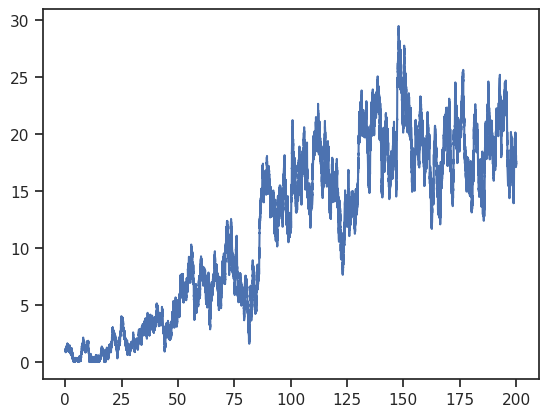

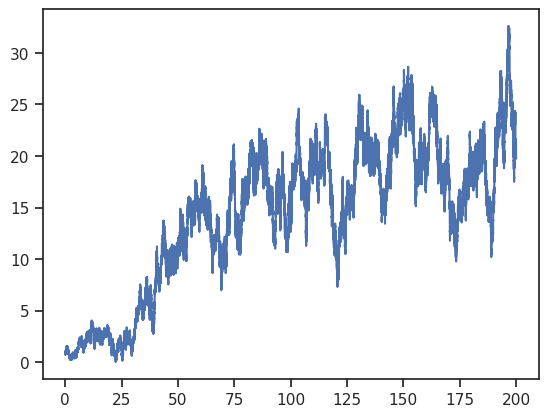

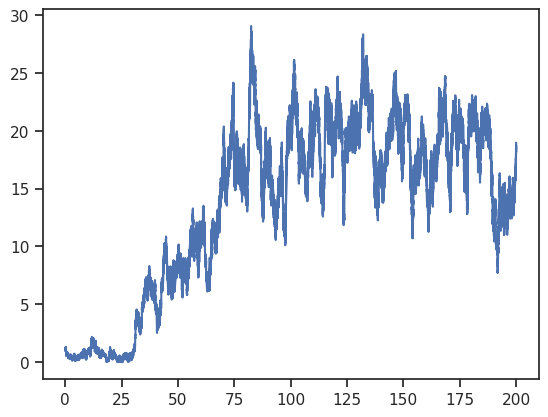

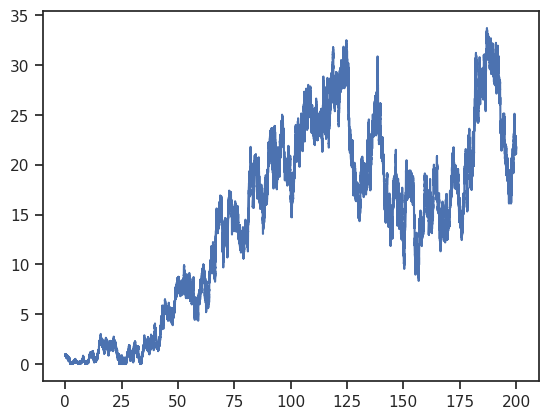

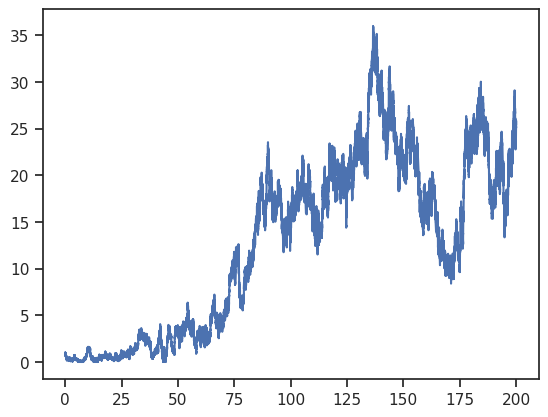

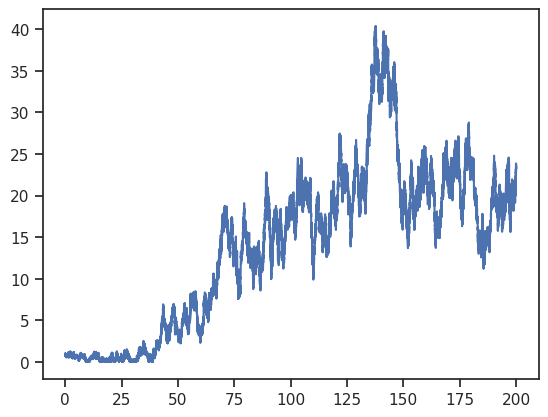

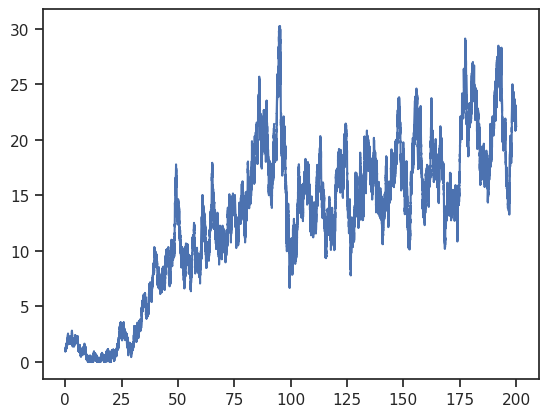

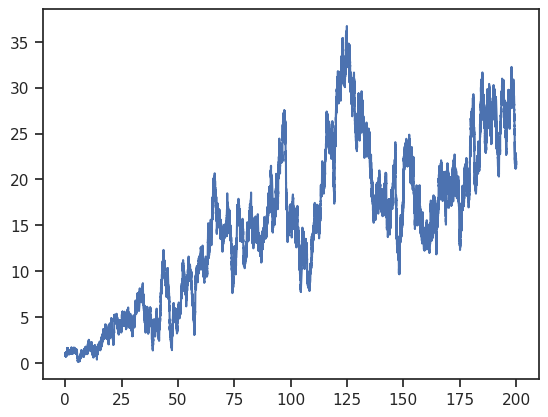

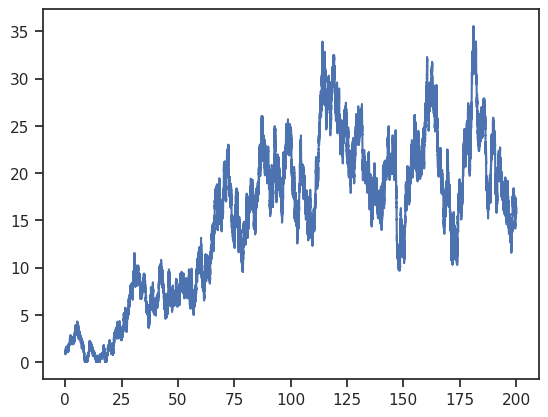

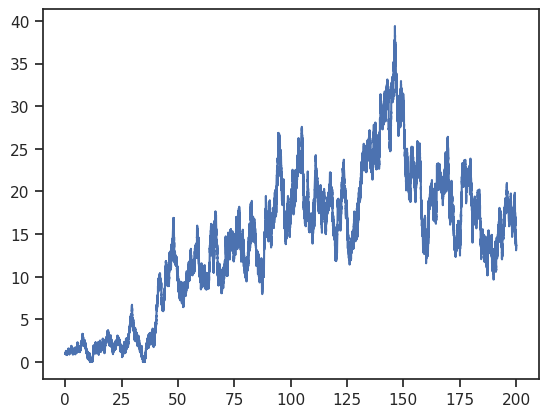

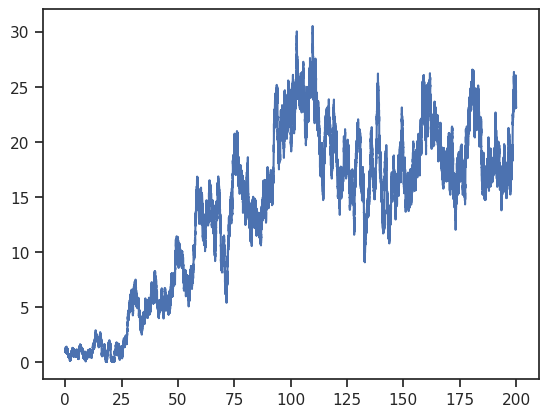

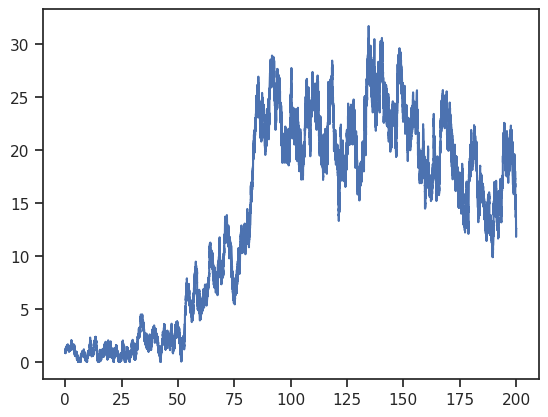

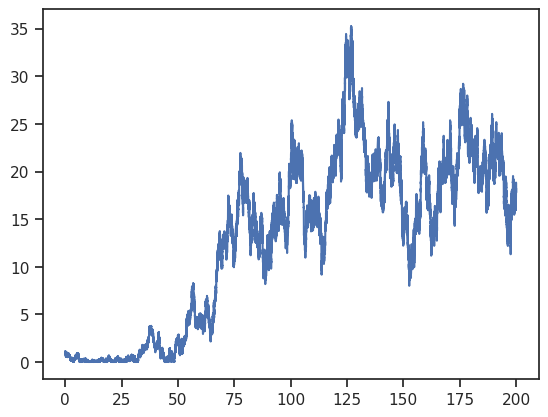

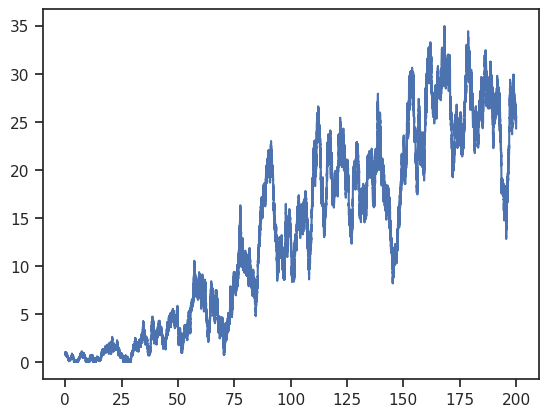

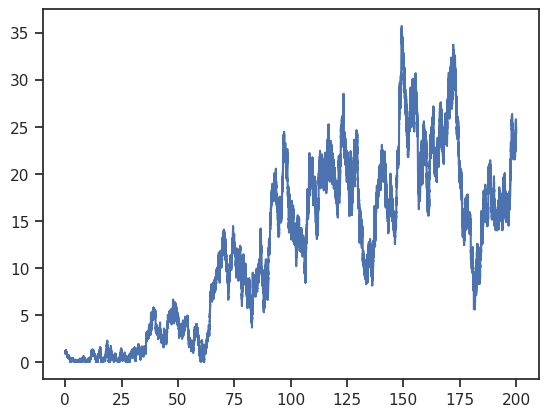

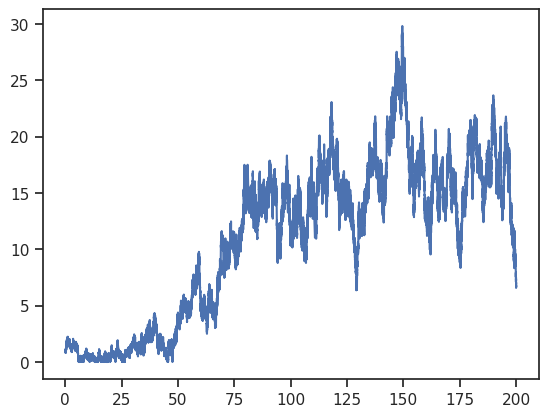

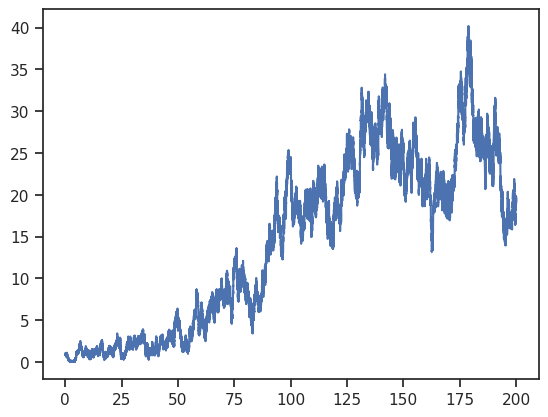

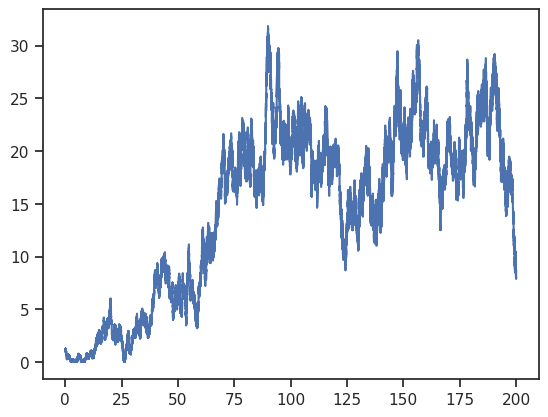

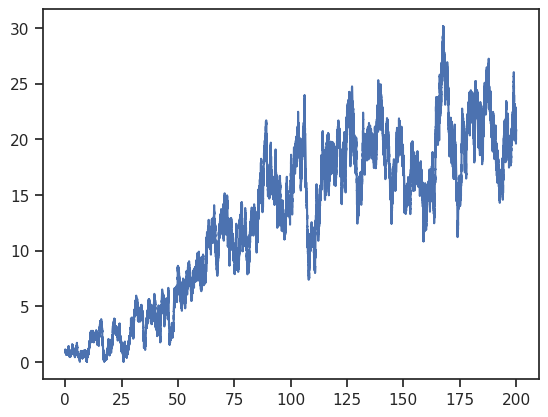

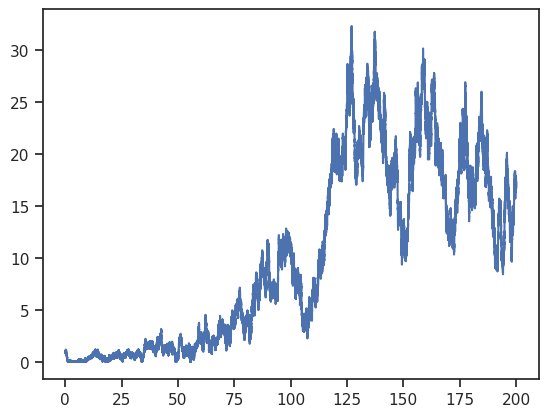

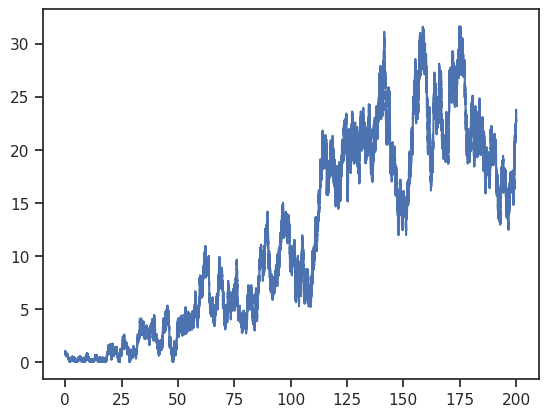

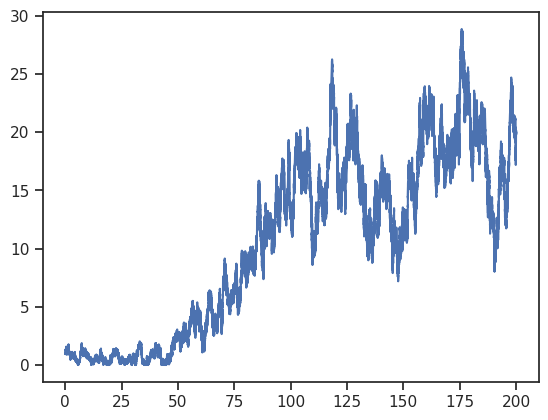

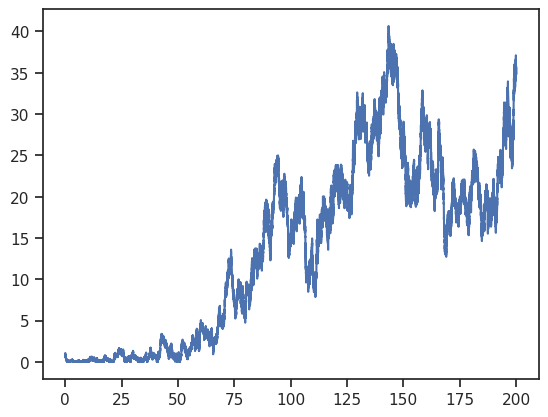

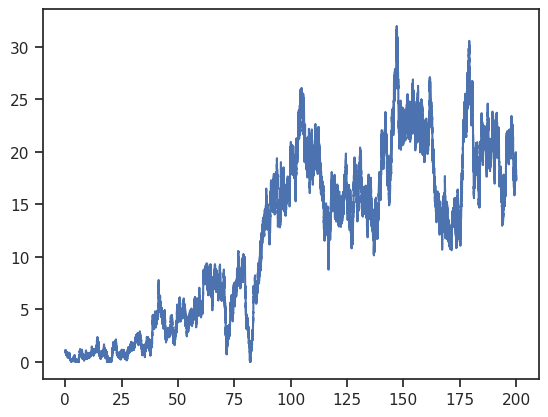

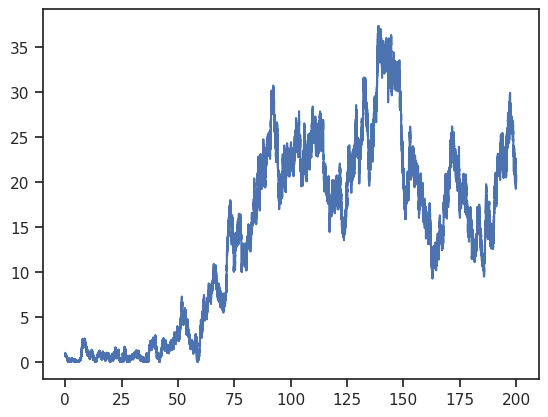

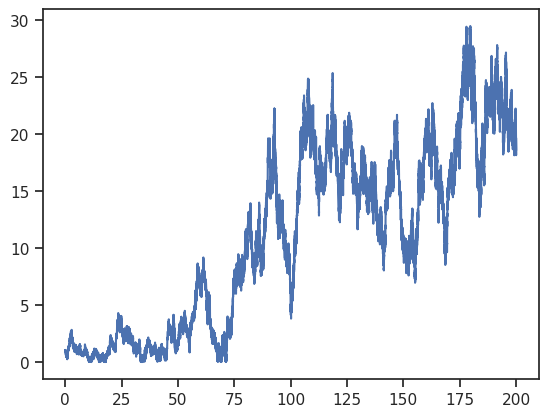

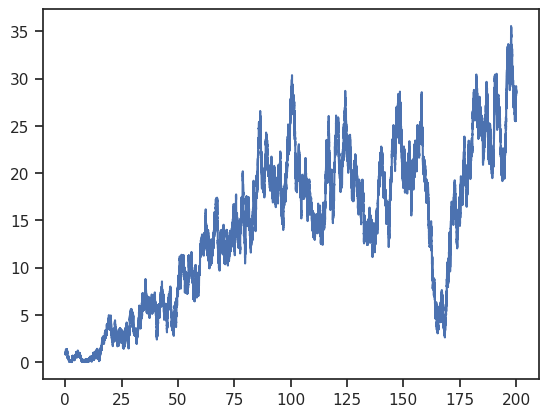

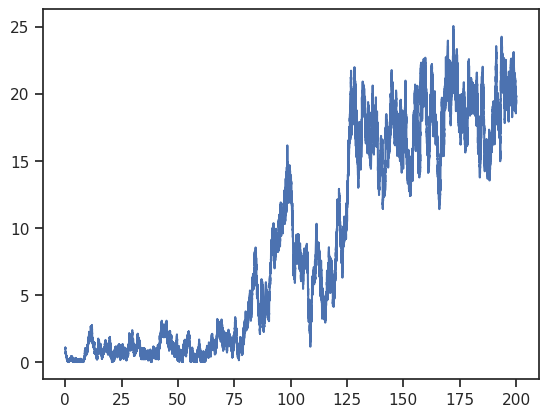

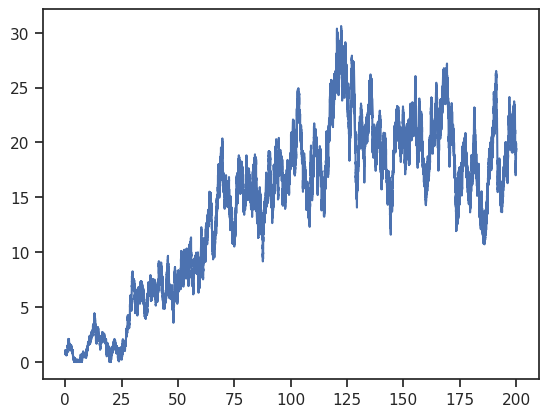

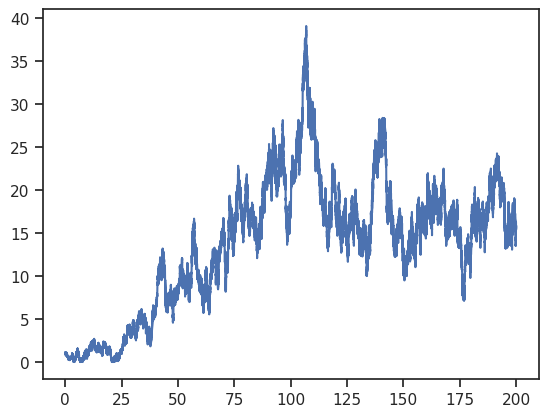

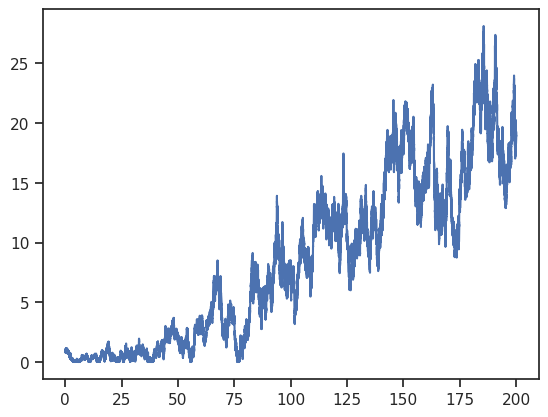

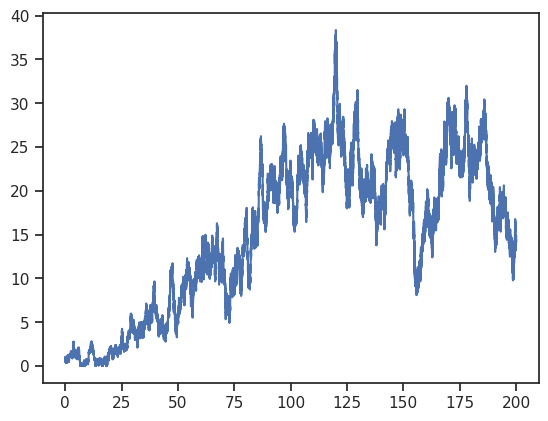

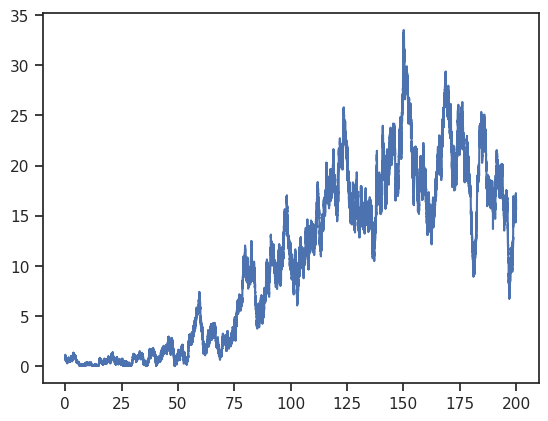

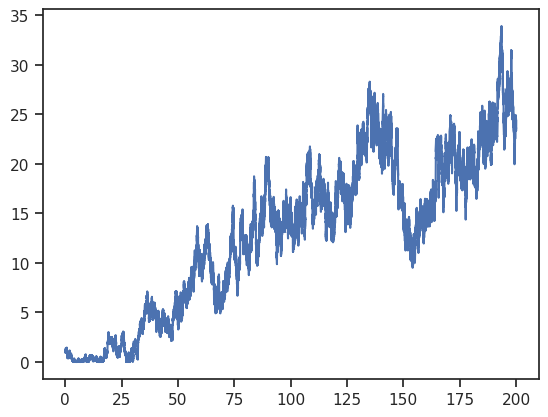

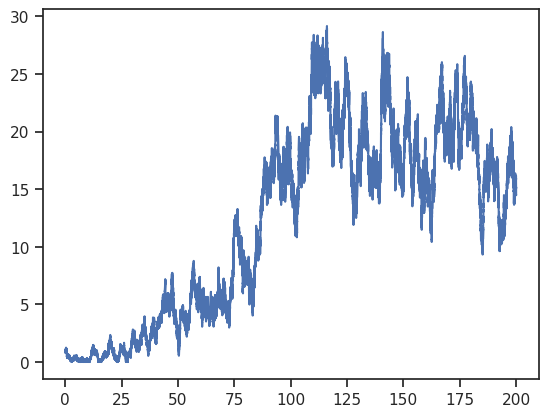

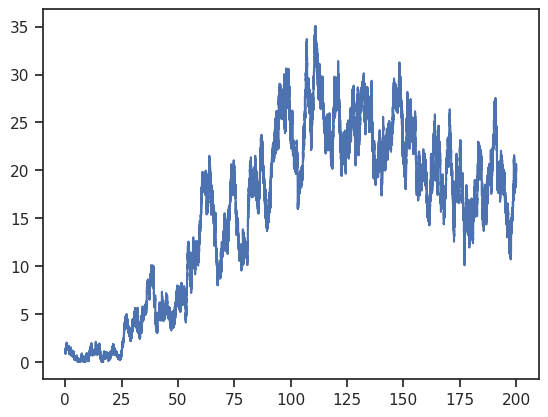

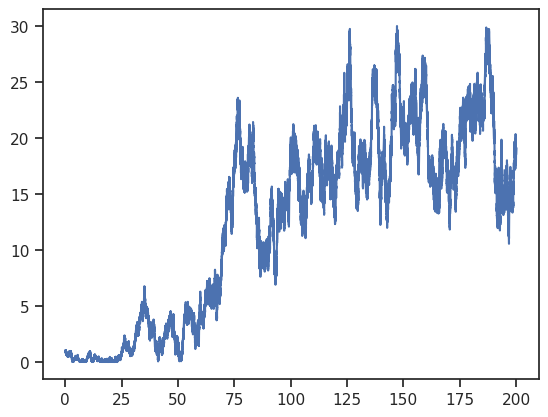

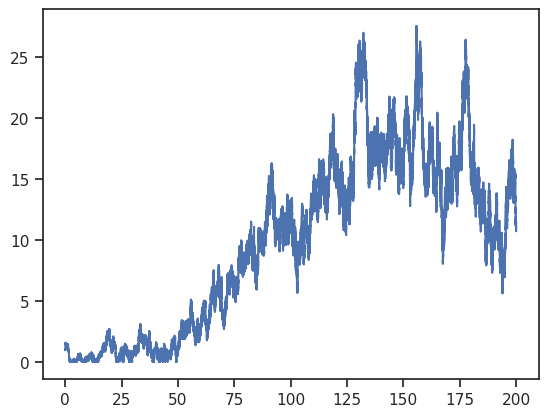

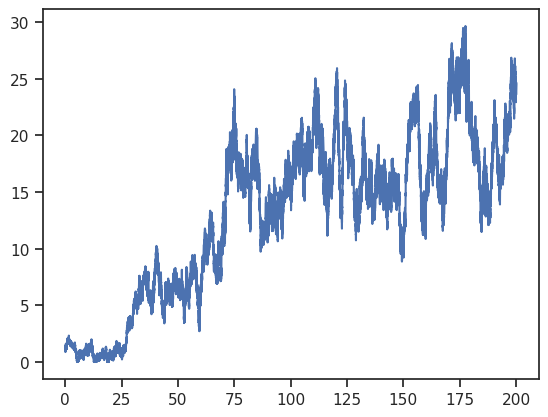

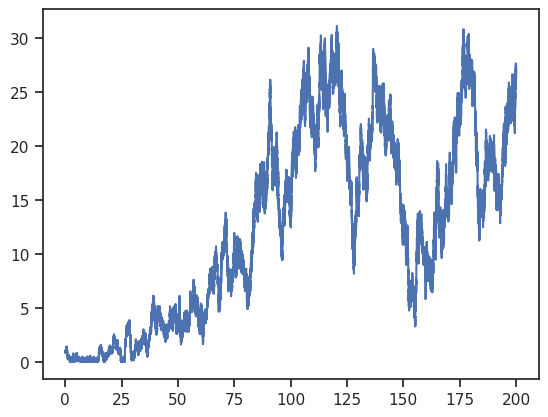

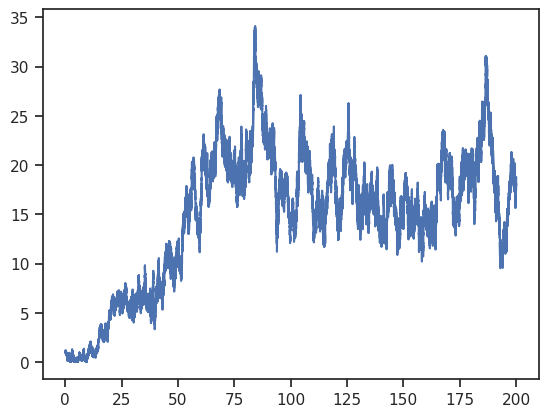

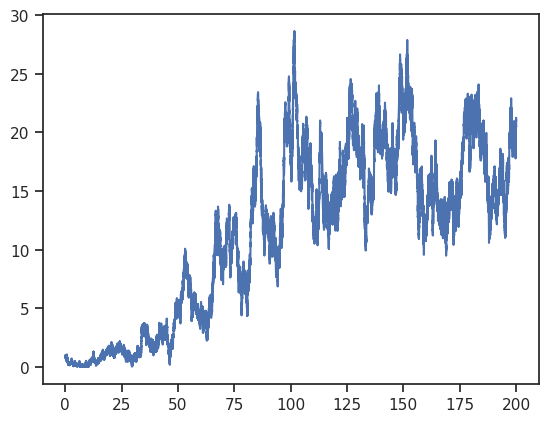

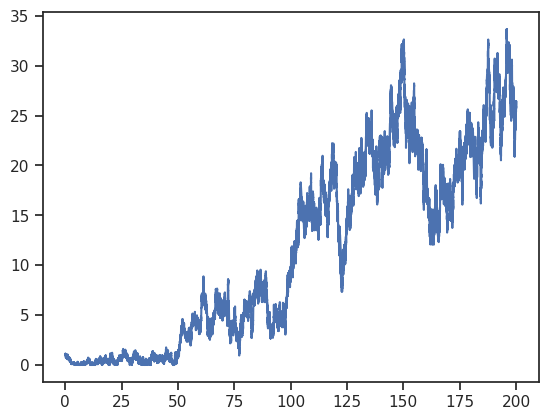

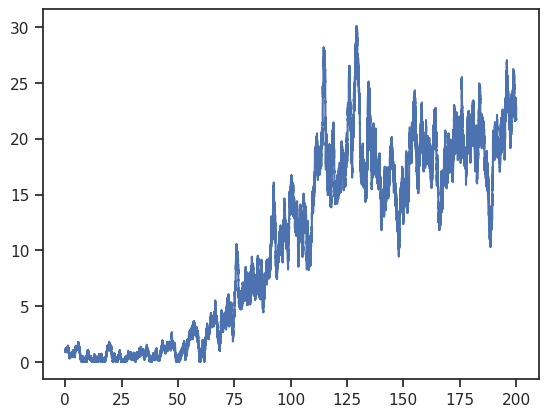

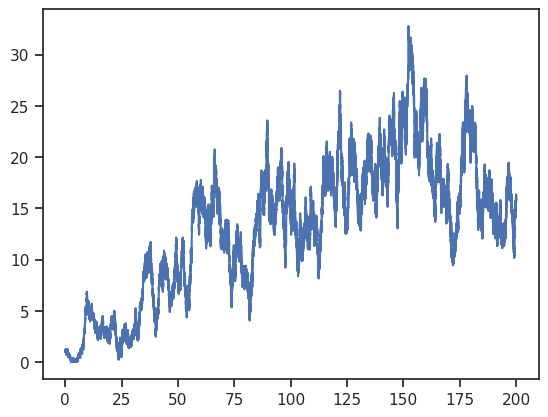

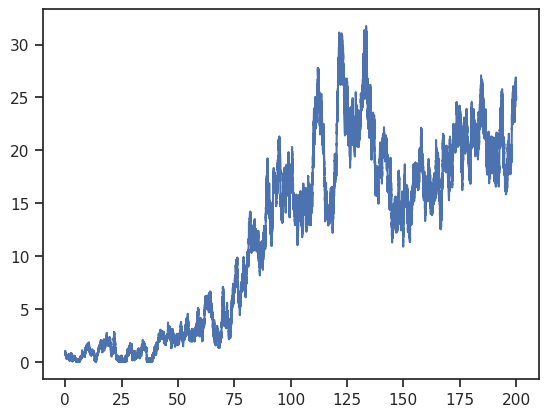

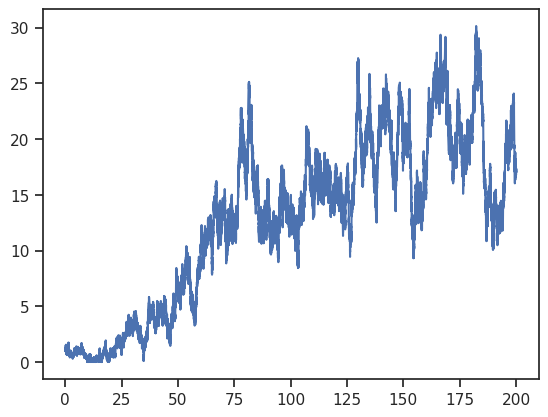

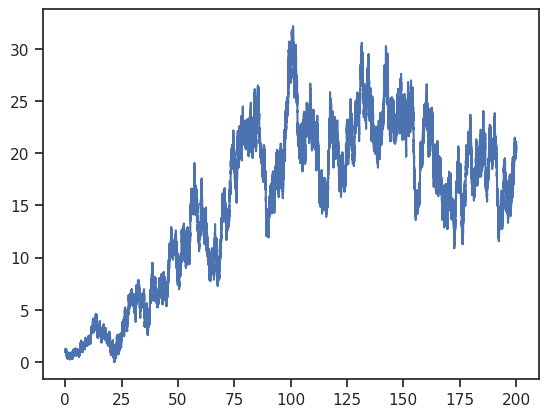

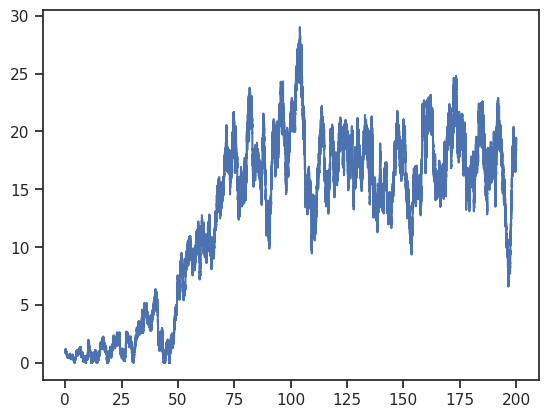

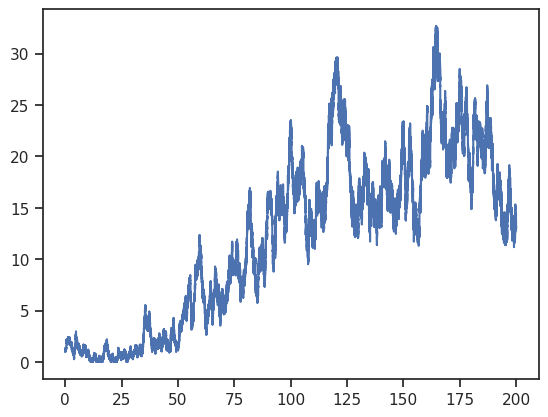

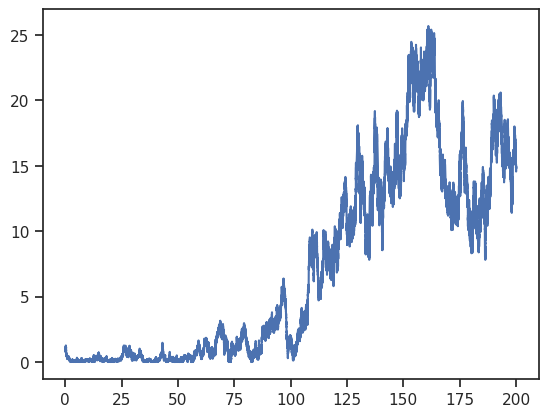

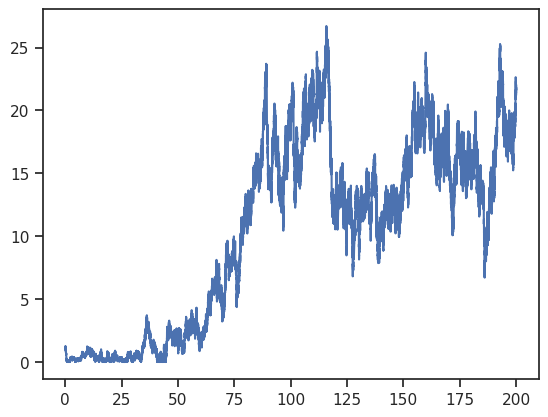

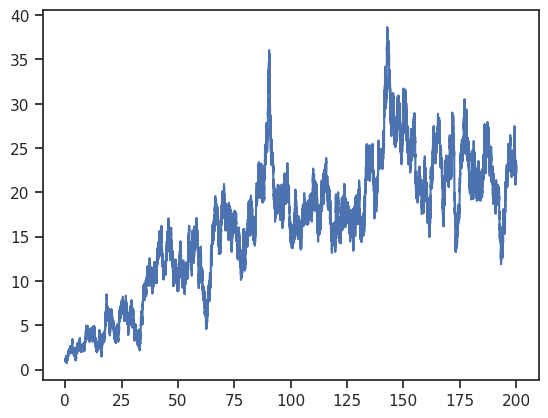

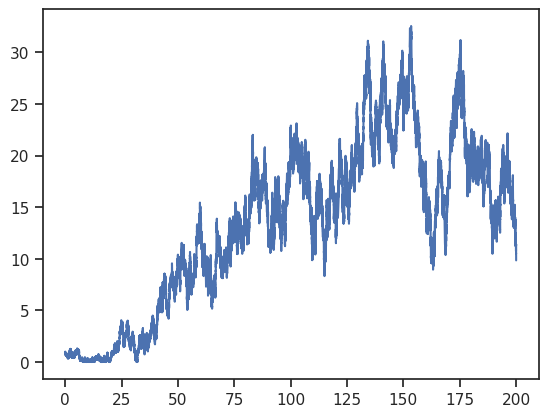

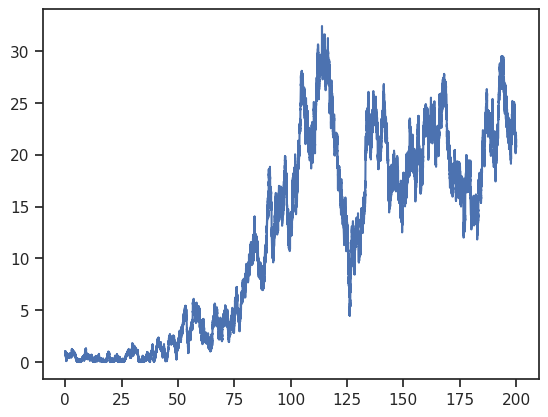

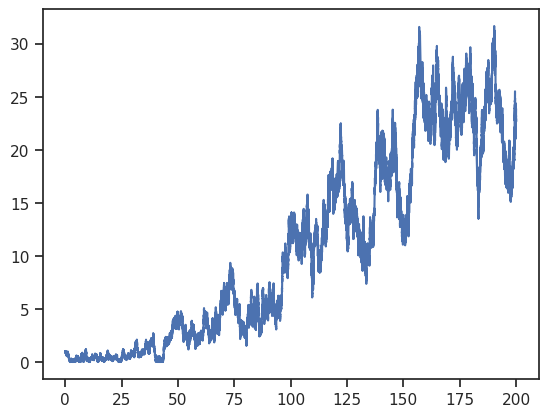

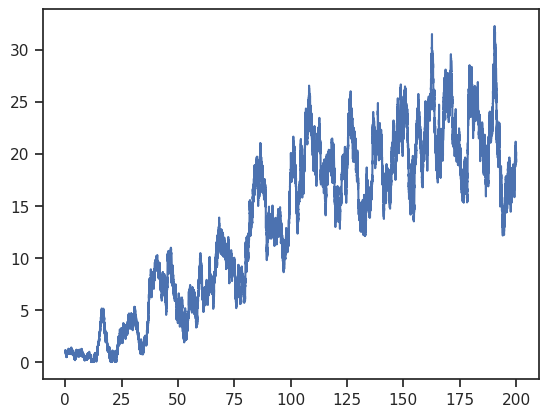

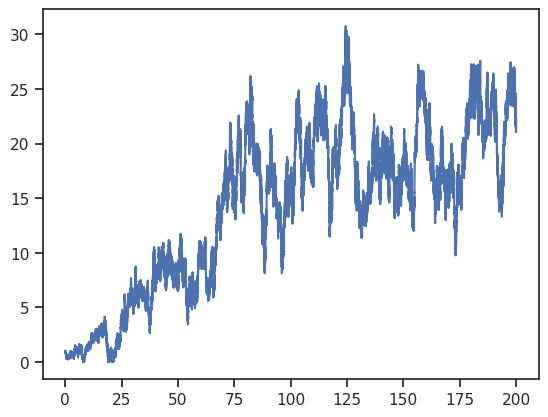

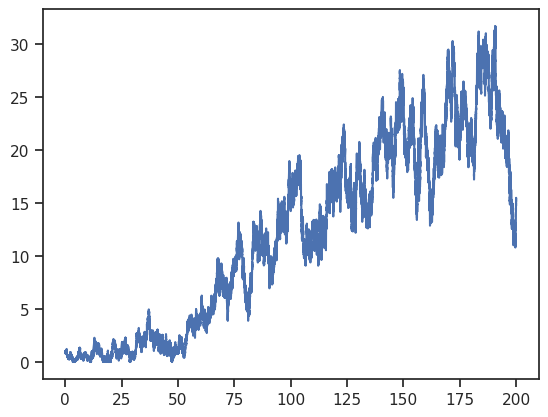

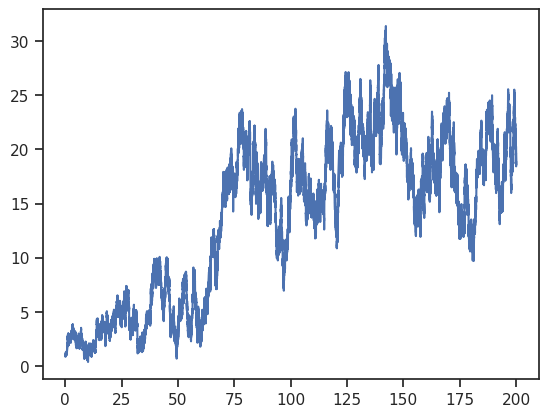

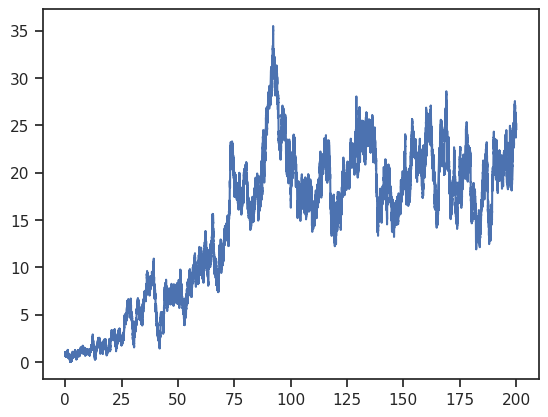

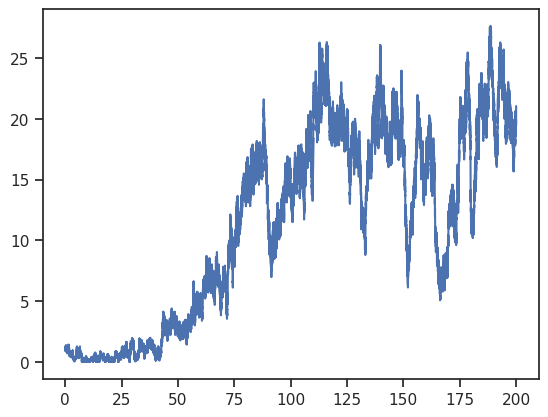

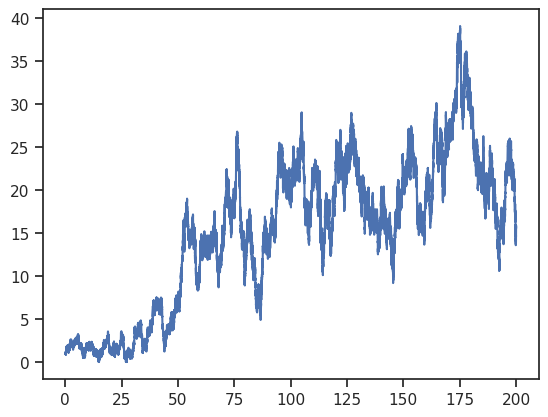

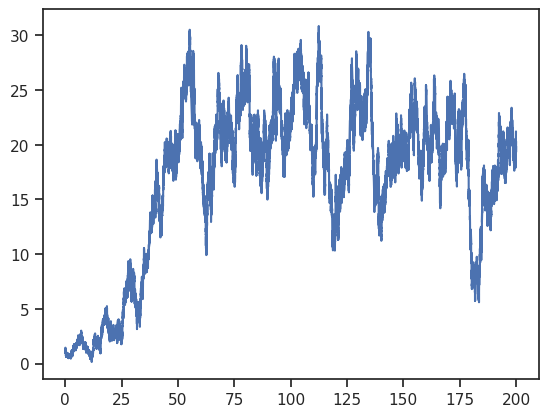

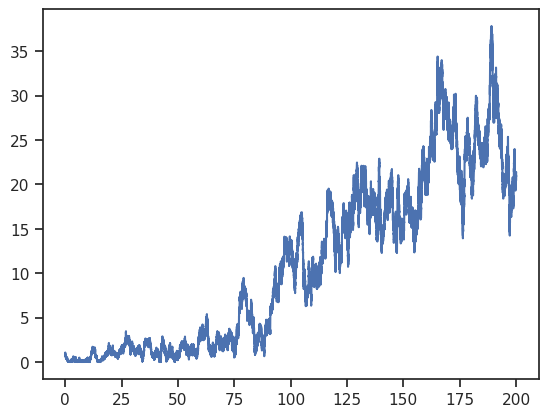

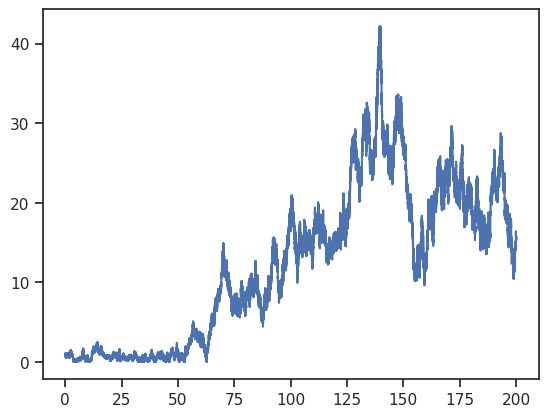

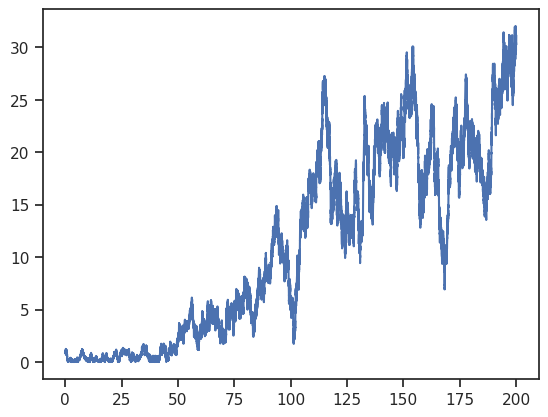

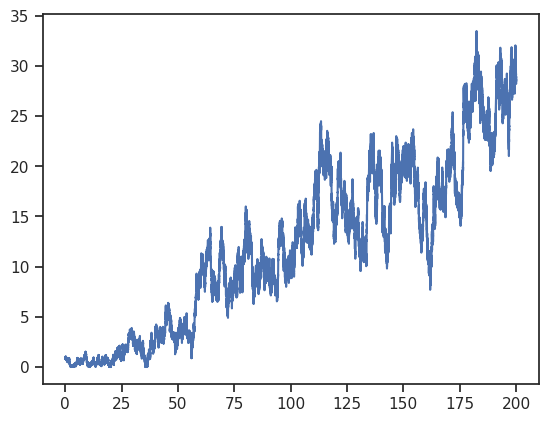

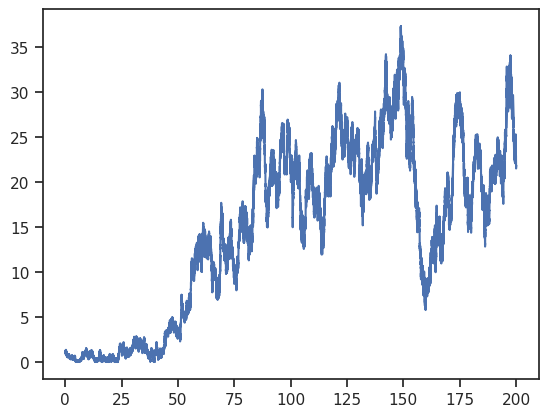

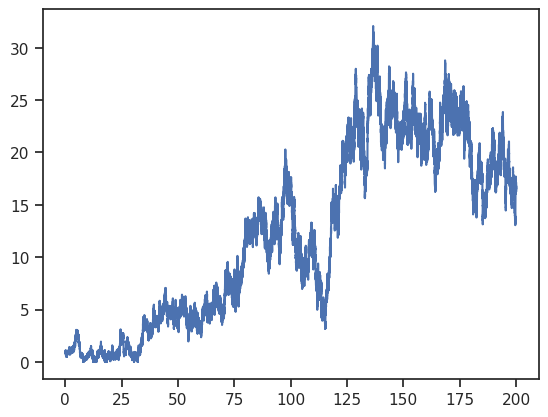

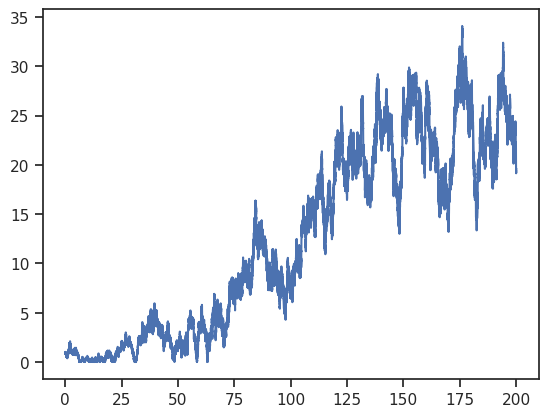

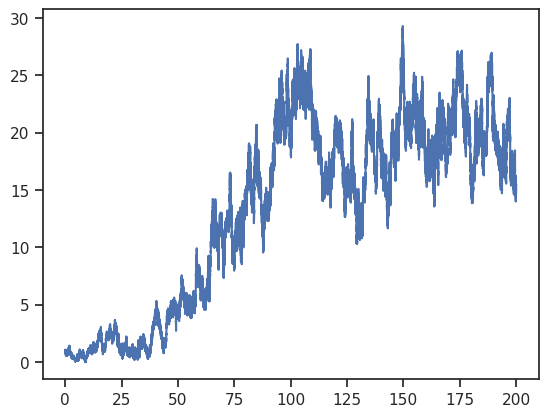

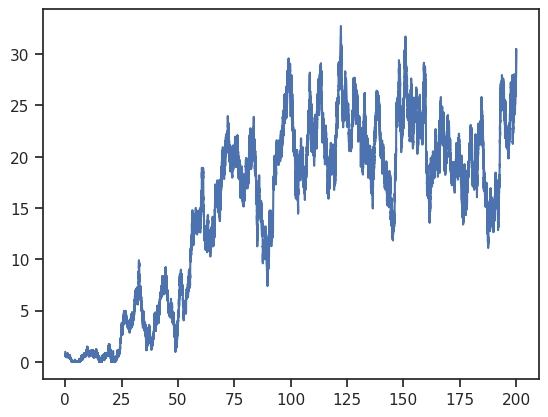

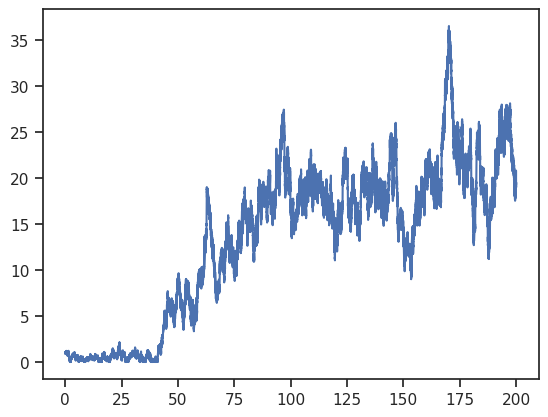

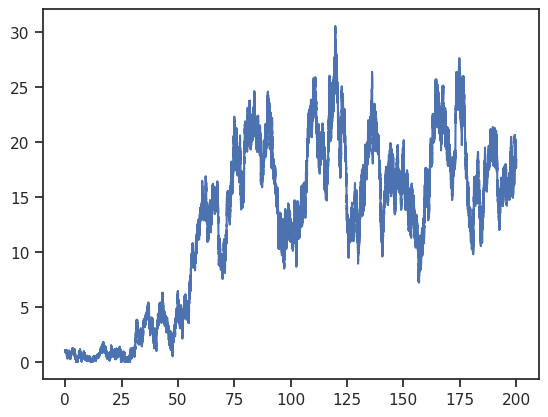

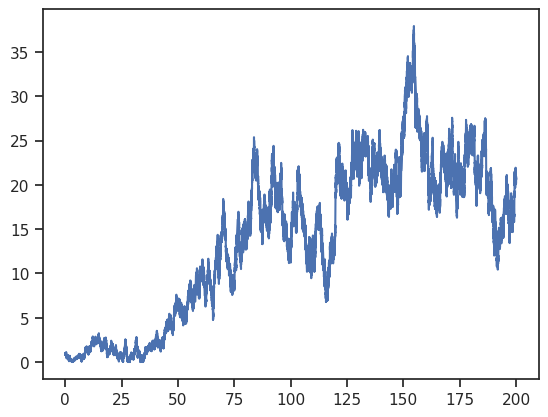

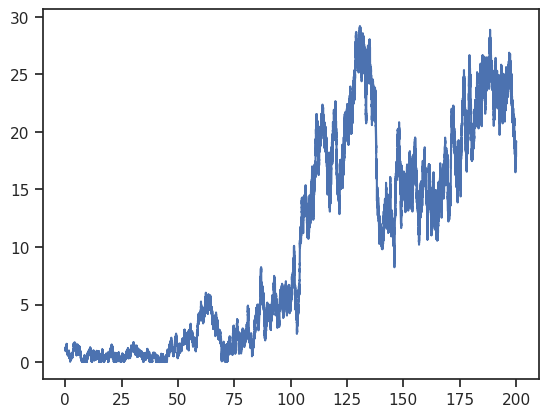

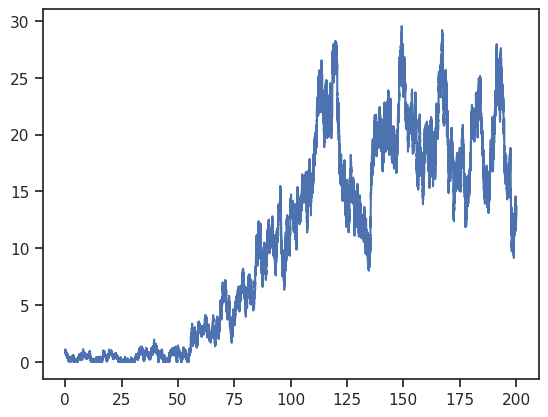

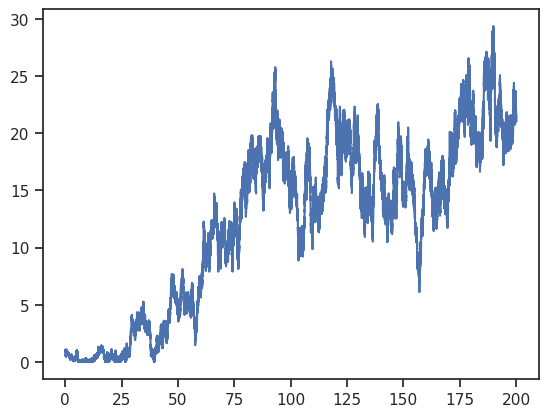

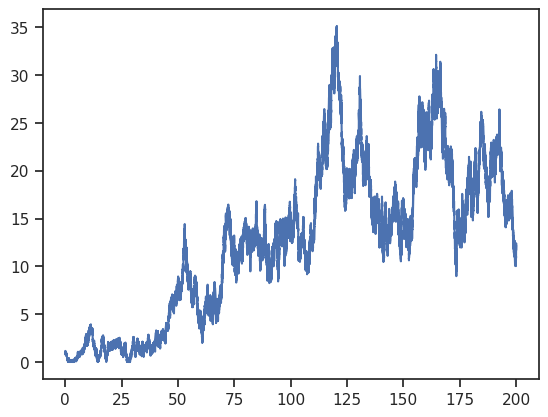

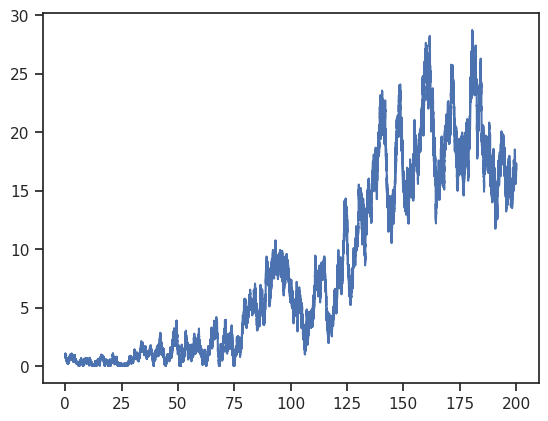

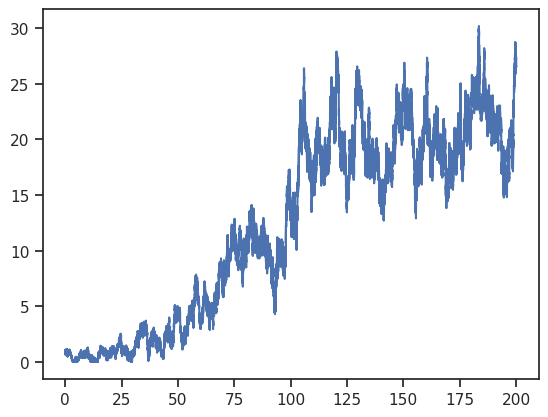

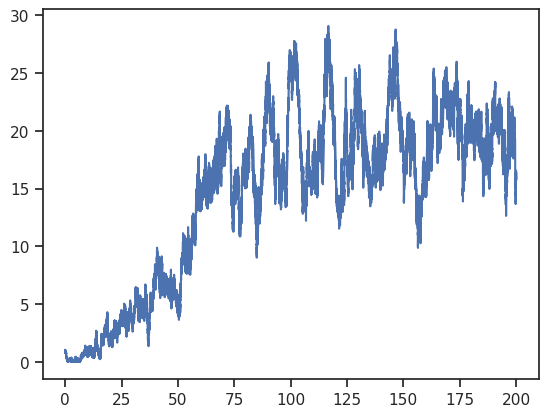

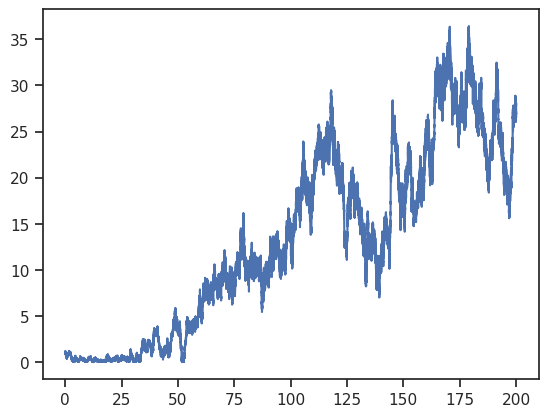

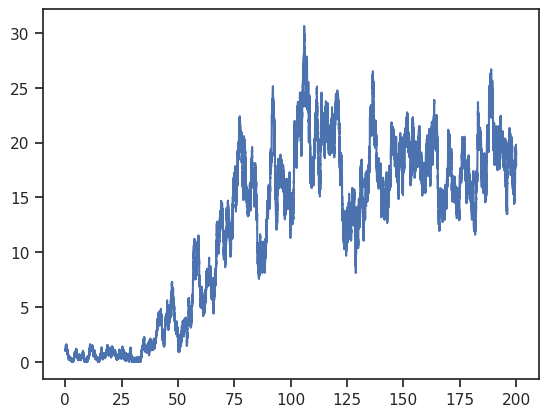

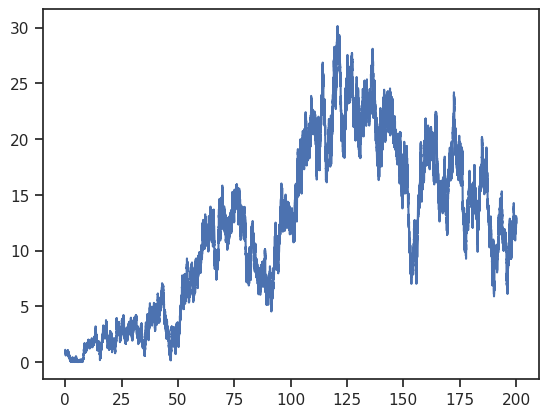

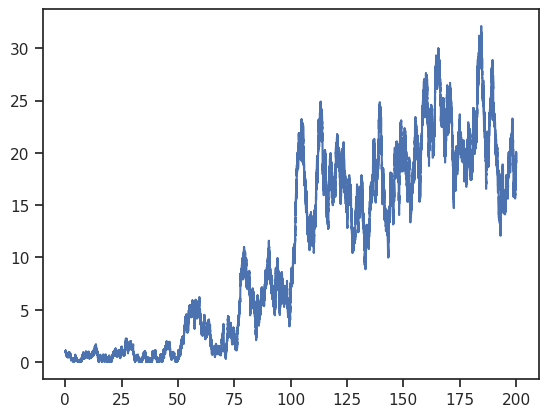

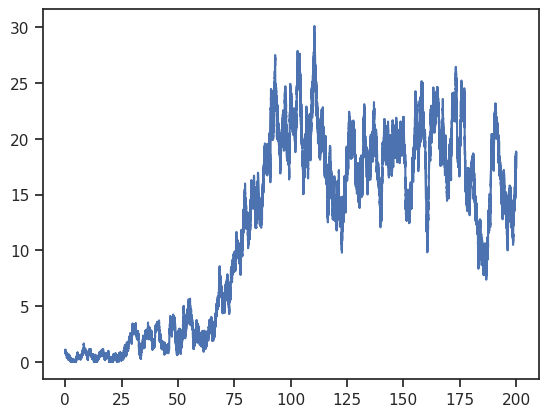

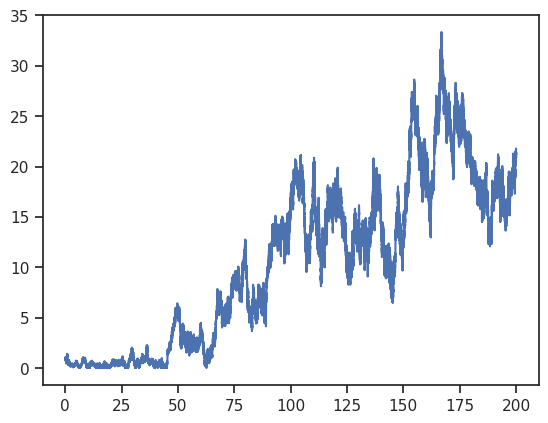

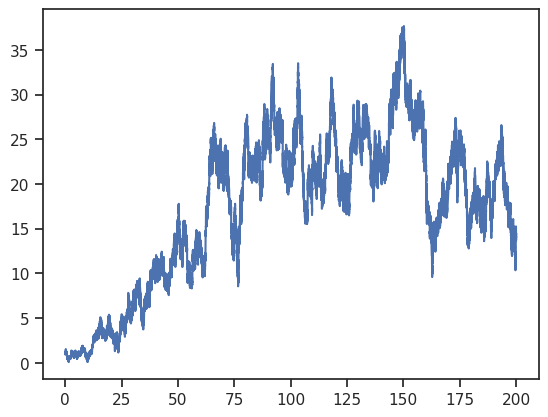

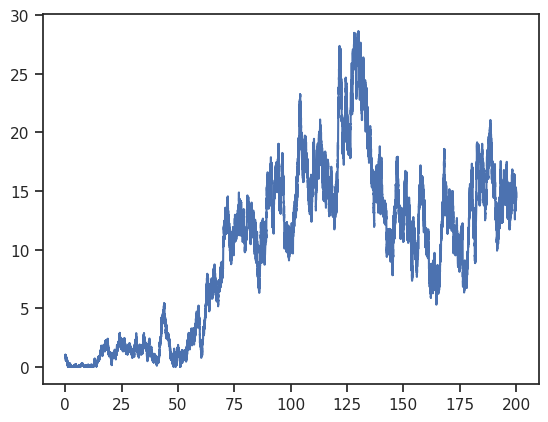

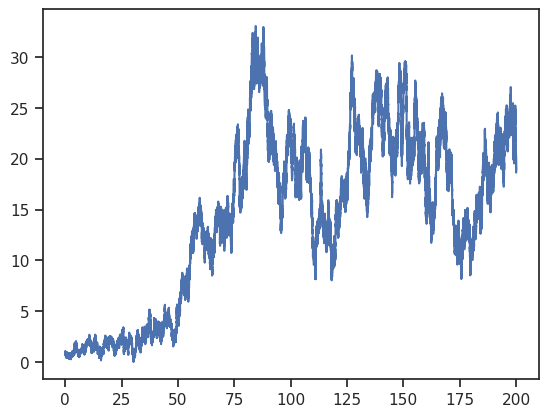

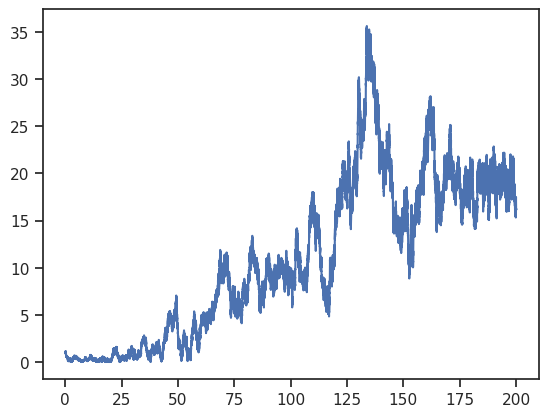

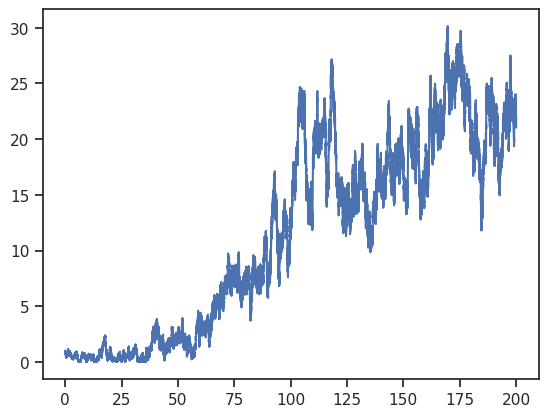

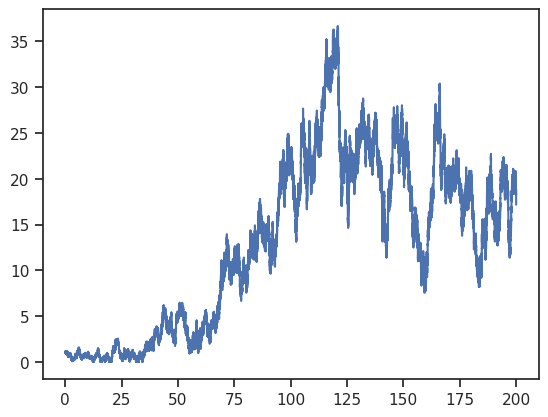

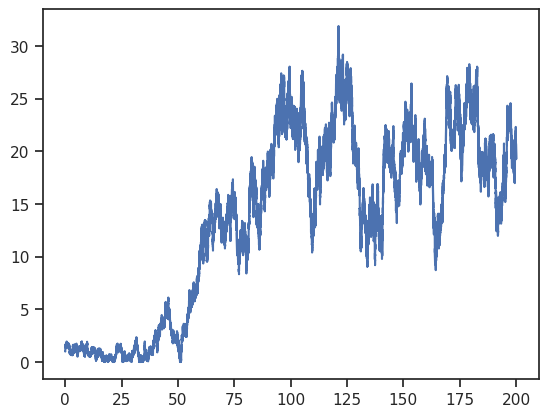

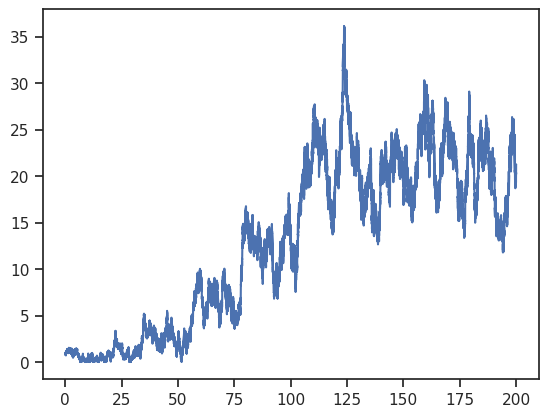

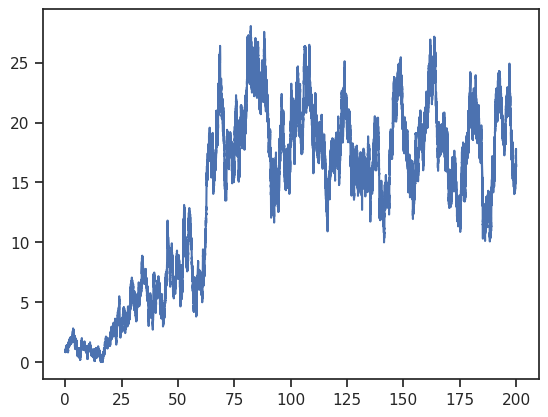

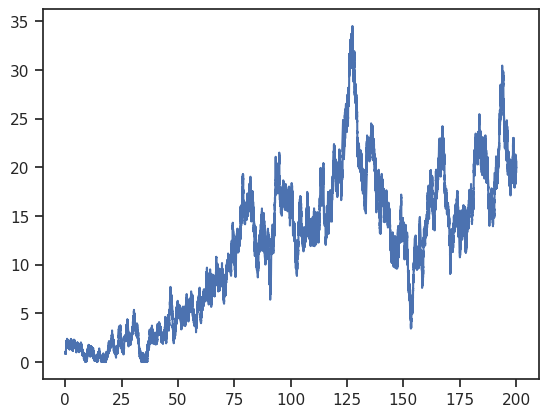

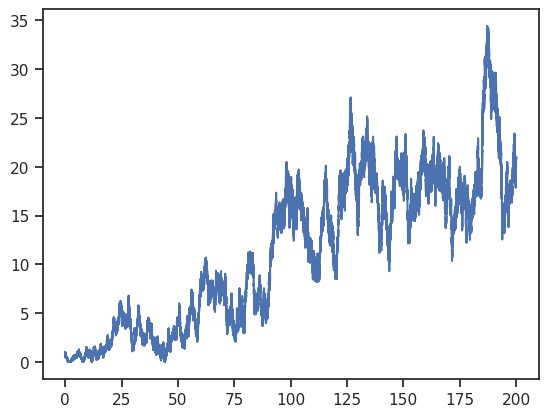

In [37]:
#print(result_cle[0][0].shape)
for i in range(100):
    plt.plot(result_cle[i][0],result_cle[i][1][:,1])
    plt.show()

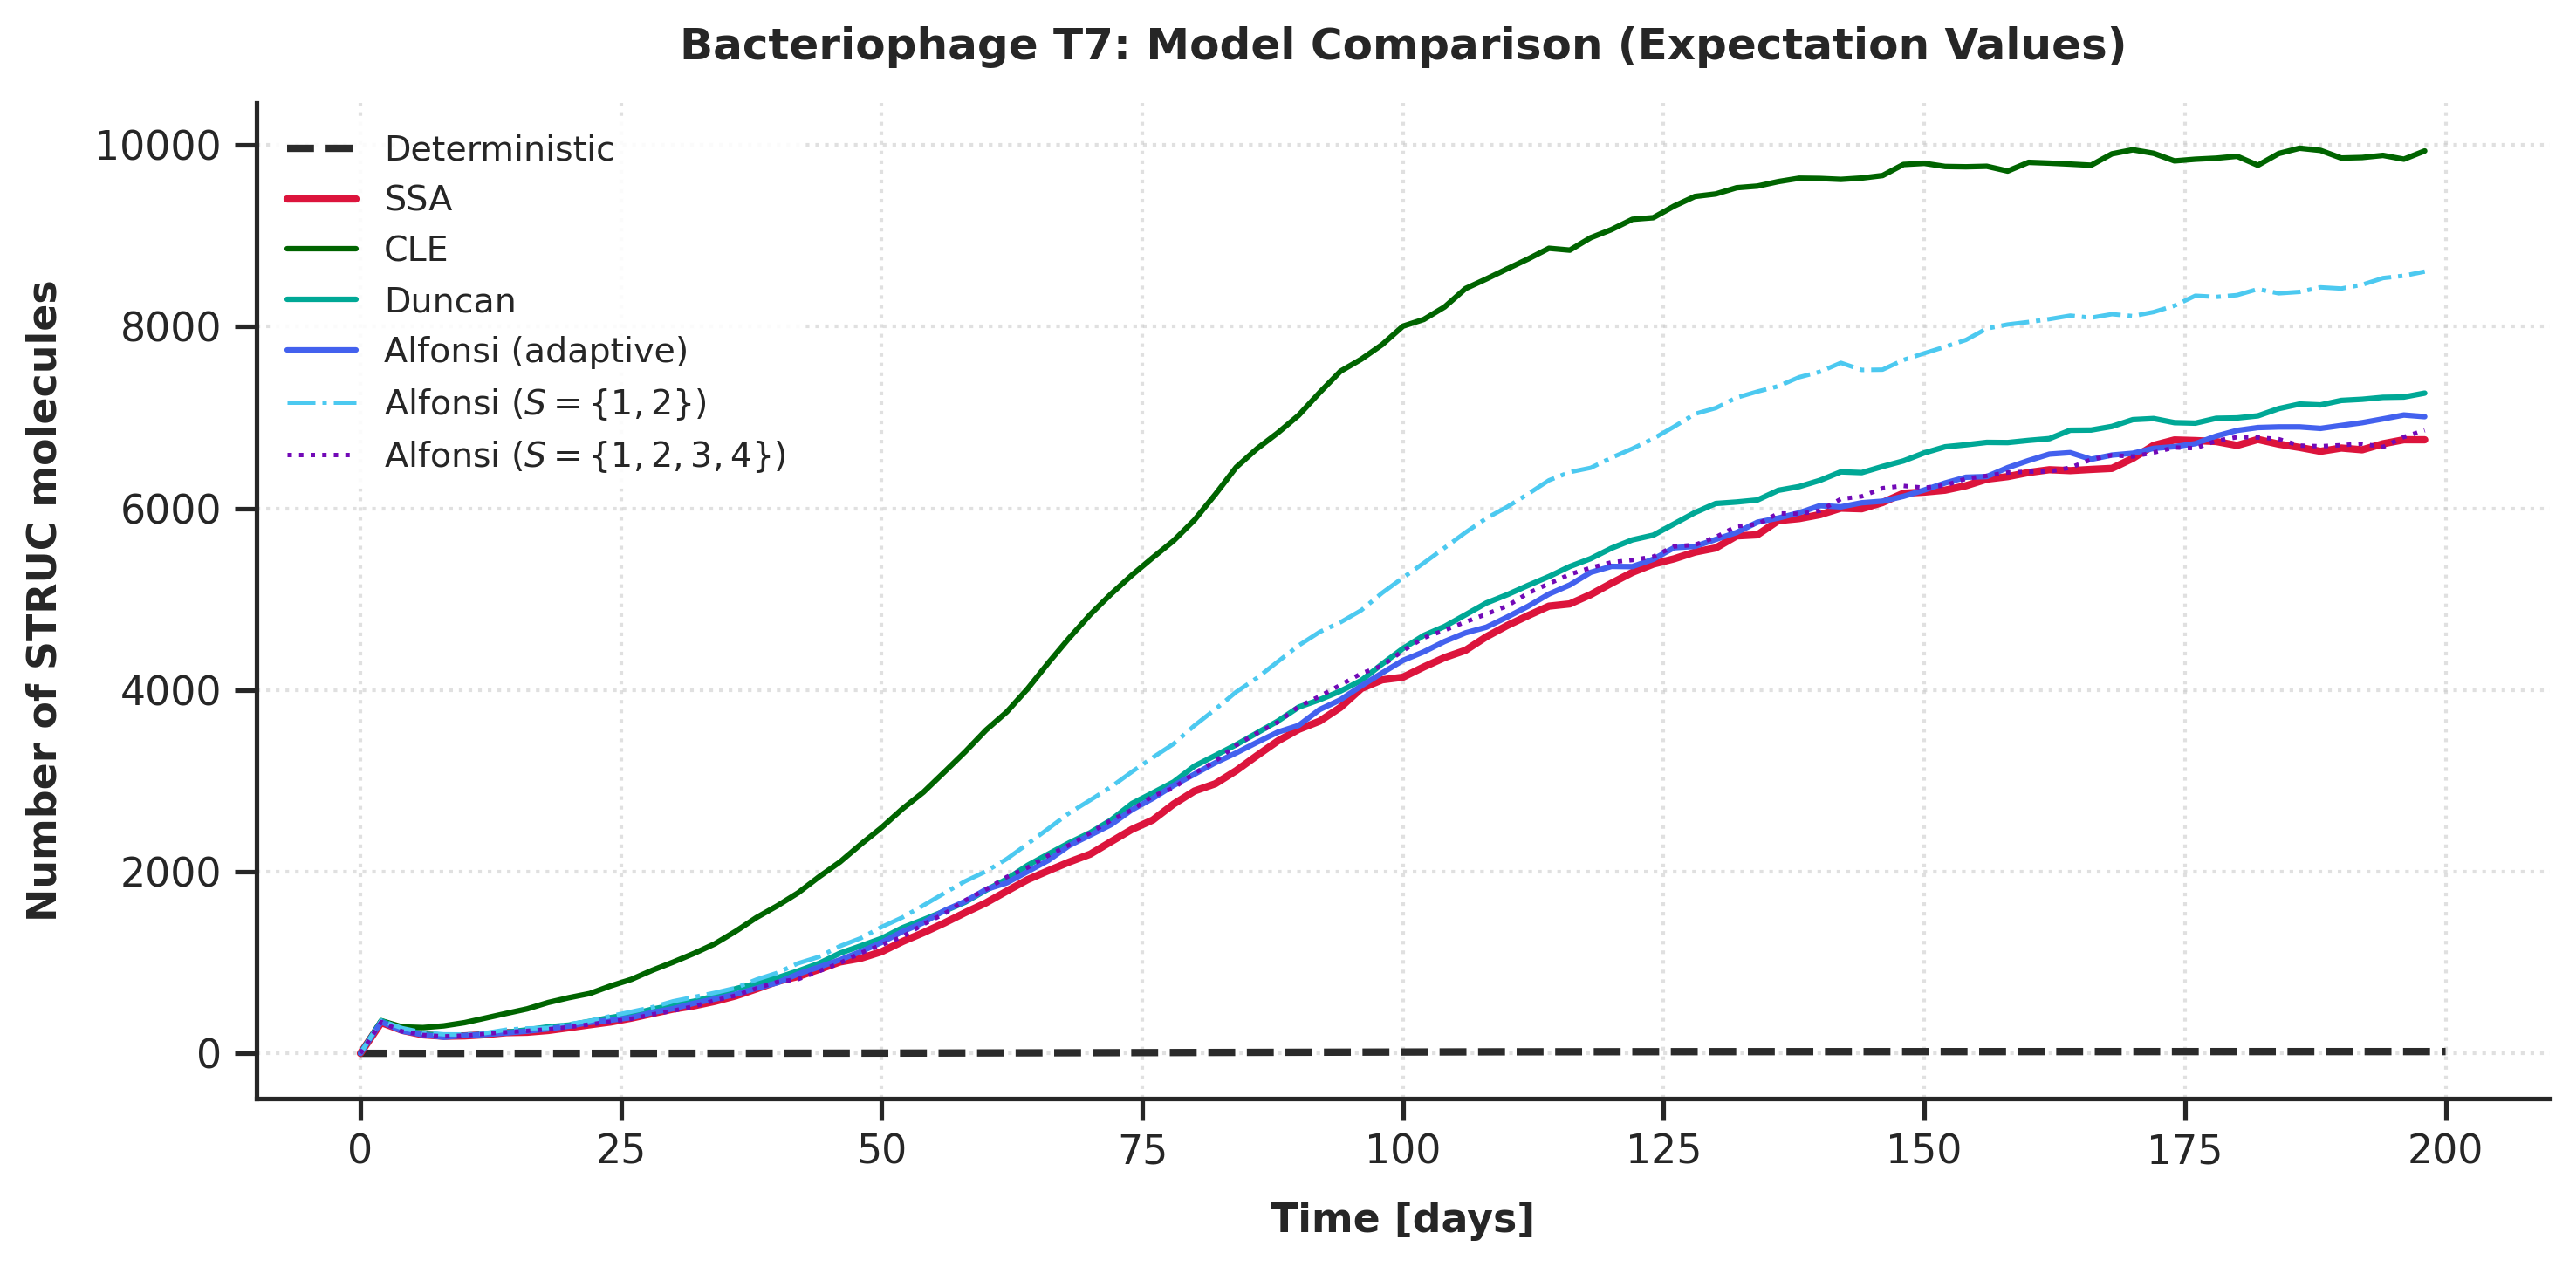

In [20]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


t_range = np.arange(0, 200, 2)
sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(10, 5),dpi=300)
ax.plot(bacteriophage.t, tem, label="Deterministic", color="#2b2b2b", linewidth=2, linestyle="--")
ax.plot(t_range, ssa_exp[:,2], label="SSA", color="crimson", linewidth=2)
ax.plot(t_range, cle_exp[:,2], label="CLE", color="darkgreen", linewidth=1.5)
ax.plot(t_range, duncan_exp[:,2], label="Duncan", color="#00a896", linewidth=1.5)
ax.plot(t_range, alfonsi_exp[:,2], label="Alfonsi (adaptive)", color="#4361ee", linewidth=1.5)
ax.plot(t_range, alfonsi_set_small_exp[:,2], label=r"Alfonsi ($S=\{1,2\}$)", color="#4cc9f0", linewidth=1.2, linestyle="-.")
ax.plot(t_range, alfonsi_set_huge_exp[:,2], label=r"Alfonsi ($S=\{1,2,3,4\}$)", color="#7209b7", linewidth=1.2, linestyle=":")
ax.set_xlabel("Time [days]", fontsize=11, fontweight="bold", labelpad=8)
ax.set_ylabel("Number of STRUC molecules", fontsize=11, fontweight="bold", labelpad=8)
ax.set_title("Bacteriophage T7: Model Comparison (Expectation Values)", fontsize=12, pad=12, fontweight="bold")
ax.grid(True, linestyle=":", alpha=0.6)
sns.despine(top=True, right=True)
ax.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9, edgecolor="none", fontsize=9.5)
plt.tight_layout()
path2 = os.path.join("/work/scheibe5/bacteriophage_t7", "bacteriophage_model_comparison_struc_exp2.png")
plt.savefig(path2, bbox_inches="tight")
plt.show()

In [15]:

t_range = np.arange(0, 200, 2)
#alfonsi_exp = stochastinetics.expectation(result_alfonsi, n, t_range)[:,1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(bacteriophage.t, tem, label="deterministic")
ax.plot(t_range,cle_exp,label="cle")
ax.plot(t_range,ssa_exp, label="ssa")
ax.plot(t_range,duncan_exp, label="Duncan")
ax.plot(t_range,alfonsi_exp, label="alfonsi adaptive partitioning")
ax.plot(t_range,alfonsi_set_small_exp, label="alfonsi S={1,2}")
ax.plot(t_range,alfonsi_set_huge_exp, label="alfonsi S={1,2,3,4}")
ax.legend()
ax.set_xlabel("Time [days]")
ax.set_ylabel("Number of tem molecules")
ax.grid(True, linestyle=':', color='gray', alpha=0.6)
path2 = os.path.join("/work/scheibe5/bacteriophage_t7","bacteriophage_model_comparison_tem_exp.png")
plt.savefig(path2)
plt.close(fig)

### Probability Distributions over time

#### Bacterophage-Model

In [20]:
path_cle = "/work/scheibe5/bacteriophage_t7/cle/result_cle_bacteriophage.csv"
path_duncan = "/work/scheibe5/bacteriophage_t7/duncan_ssa/result_duncan_ssa_15_25_bacteriophage.csv"
path_alfonsi = "/work/scheibe5/bacteriophage_t7/alfonsi_adaptive/result_alfonsi_adaptive_60_bacteriophage.csv"
path_ssa= "/work/scheibe5/bacteriophage_t7/ssa/result_ssa_bacteriophage.csv"

In [12]:
def fill_time_dict_gen(data, path,n_state, n_simulation, time_points):
    for current_result in stochastinetics.read_in_sim_results_gen(path,n_state):
        for j,ti in enumerate(time_points):
            idx = np.searchsorted(current_result[0], ti)
            idx = np.clip(idx, 1, len(current_result[1]) - 1)
            if abs(current_result[0][idx - 1] - ti) < abs(current_result[0][idx] - ti):
                idx -= 1
            data[ti].append(current_result[1][idx].copy())
    for _,ti in enumerate(time_points):
        data[ti] = np.array(data[ti])
    return data

time_points = [1, 10, 50, 100,150,200]

data_cle = {1: [],10: [],50: [],100: [],150:[],200:[]}
data_cle = fill_time_dict_gen(data_cle, path_cle,4,1000,time_points)

1 simulation runs have been streamed successfully.
2 simulation runs have been streamed successfully.
3 simulation runs have been streamed successfully.
4 simulation runs have been streamed successfully.
5 simulation runs have been streamed successfully.
6 simulation runs have been streamed successfully.
7 simulation runs have been streamed successfully.
8 simulation runs have been streamed successfully.
9 simulation runs have been streamed successfully.
10 simulation runs have been streamed successfully.
11 simulation runs have been streamed successfully.
12 simulation runs have been streamed successfully.
13 simulation runs have been streamed successfully.
14 simulation runs have been streamed successfully.
15 simulation runs have been streamed successfully.
16 simulation runs have been streamed successfully.
17 simulation runs have been streamed successfully.
18 simulation runs have been streamed successfully.
19 simulation runs have been streamed successfully.
20 simulation runs ha

In [27]:
import os
import pickle
import numpy as np

speicher_pfad = "/work/scheibe5/bacteriophage_t7/duncan_ssa/probability_dist.pkl"

with open(speicher_pfad, "wb") as f:
    pickle.dump(data_cle, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Dictionary erfolgreich gespeichert!")

Dictionary erfolgreich gespeichert!


In [19]:
import pickle
speicher_pfad = "/work/scheibe5/bacteriophage_t7/alfonsi_adaptive/probability_dist.pkl"

with open(speicher_pfad, "rb") as f:
    data_alfonsi = pickle.load(f)

print("Dictionary erfolgreich geladen!")

# Test-Ausgabe zur Kontrolle der Struktur:
for zeitpunkt, array in data_alfonsi.items():
    print(f"Zeitpunkt: {zeitpunkt} -> Array-Form: {array.shape}")

Dictionary erfolgreich geladen!
Zeitpunkt: 1 -> Array-Form: (1000, 3)
Zeitpunkt: 10 -> Array-Form: (1000, 3)
Zeitpunkt: 50 -> Array-Form: (1000, 3)
Zeitpunkt: 100 -> Array-Form: (1000, 3)
Zeitpunkt: 150 -> Array-Form: (1000, 3)
Zeitpunkt: 200 -> Array-Form: (1000, 3)


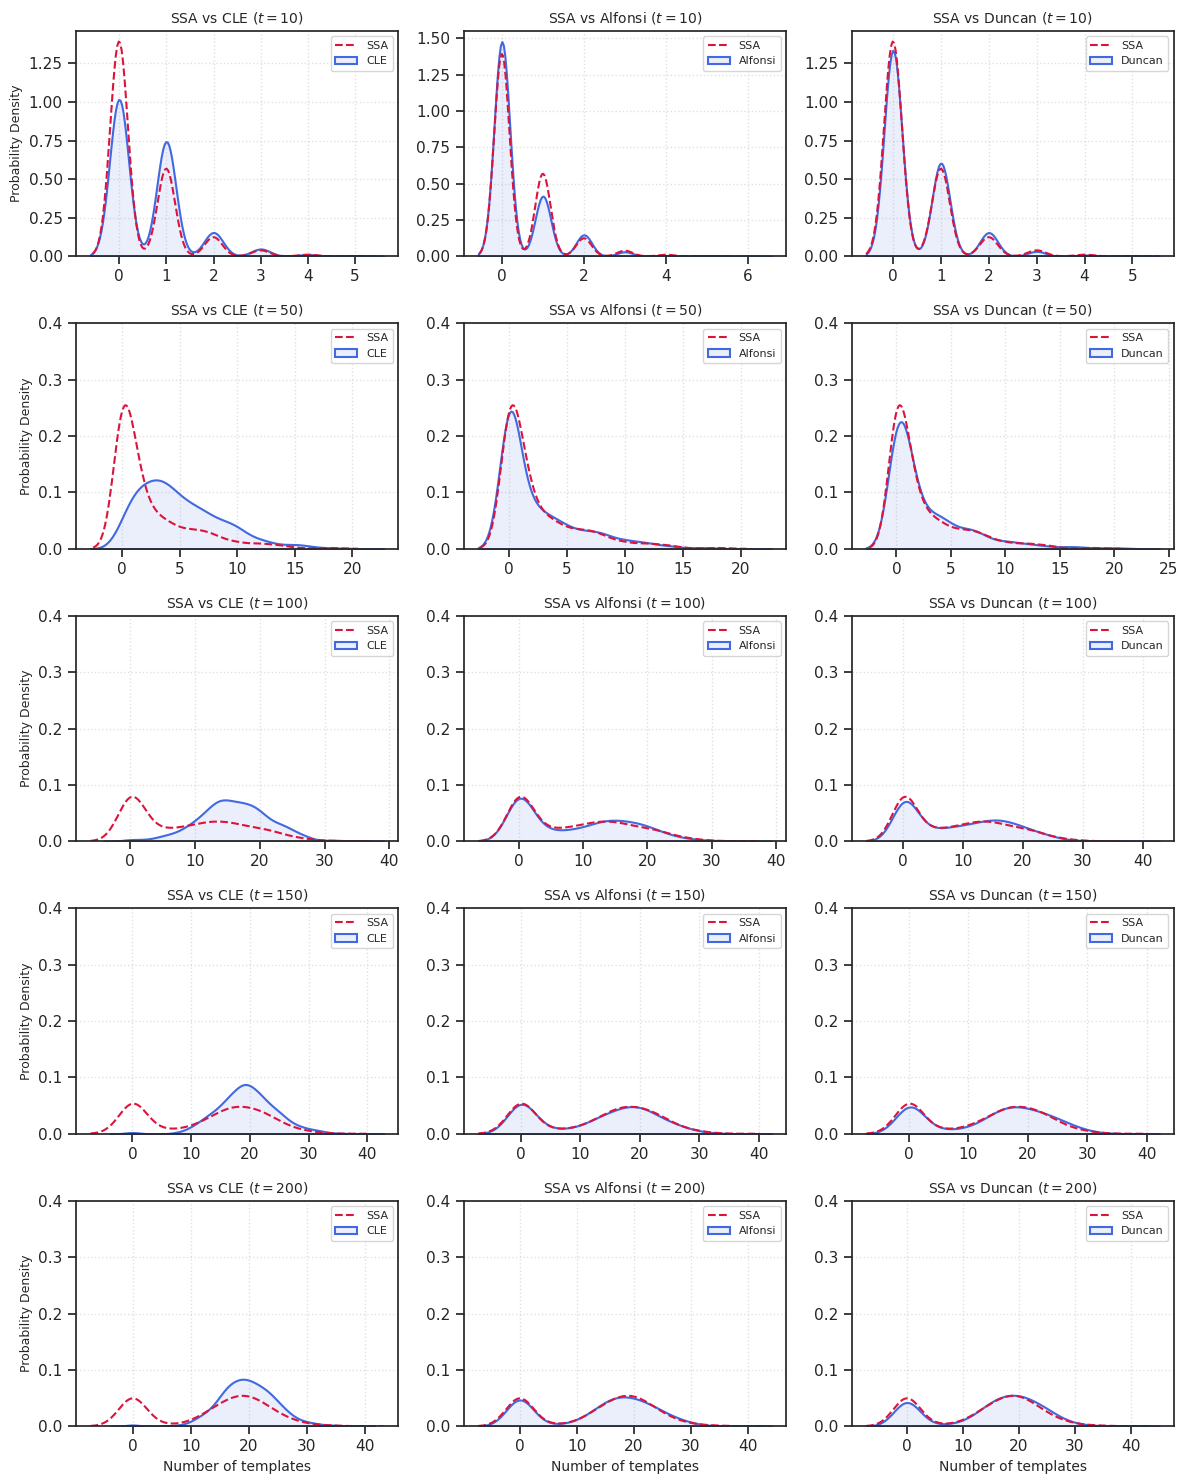

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

time_points = [10, 50, 100,150,200]
n_rows = len(time_points)


fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(12, 3 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(data_ssa[t][:,1],ax=ax_left, color="crimson", linestyle= "--",label="SSA",linewidth=1.5)
    sns.kdeplot(np.round(data_cle[t][:,1]),ax=ax_left,color="royalblue",label="CLE",linewidth=1.5,fill=True,alpha=0.1)
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,1], ax=ax_mid,color="crimson", linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(np.round(data_alfonsi[t][:,1]) ,ax=ax_mid, color="royalblue",label="Alfonsi",linewidth=1.5,fill=True, alpha=0.1)
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,1], color="crimson", ax=ax_right,linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(data_duncan_ssa[t][:,1], ax=ax_right, color = "royalblue",label="Duncan",linewidth=1.5,fill=True, alpha=0.1)
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10)

    ax_left.legend(loc="upper right", fontsize=8, frameon=True)
    ax_mid.legend(loc="upper right", fontsize=8, frameon=True)
    ax_right.legend(loc="upper right", fontsize=8, frameon=True)

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        
    if row_idx > 0:     
        ax_left.set_ylim([0,0.4])
        ax_mid.set_ylim([0,0.4])
        ax_right.set_ylim([0,0.4])
    ax_left.set_ylabel("Probability Density", fontsize=9)

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of templates", fontsize=10)

plt.tight_layout()
plt.savefig("/work/scheibe5/bacteriophage_t7/probability_dist_templates.png")
plt.show()

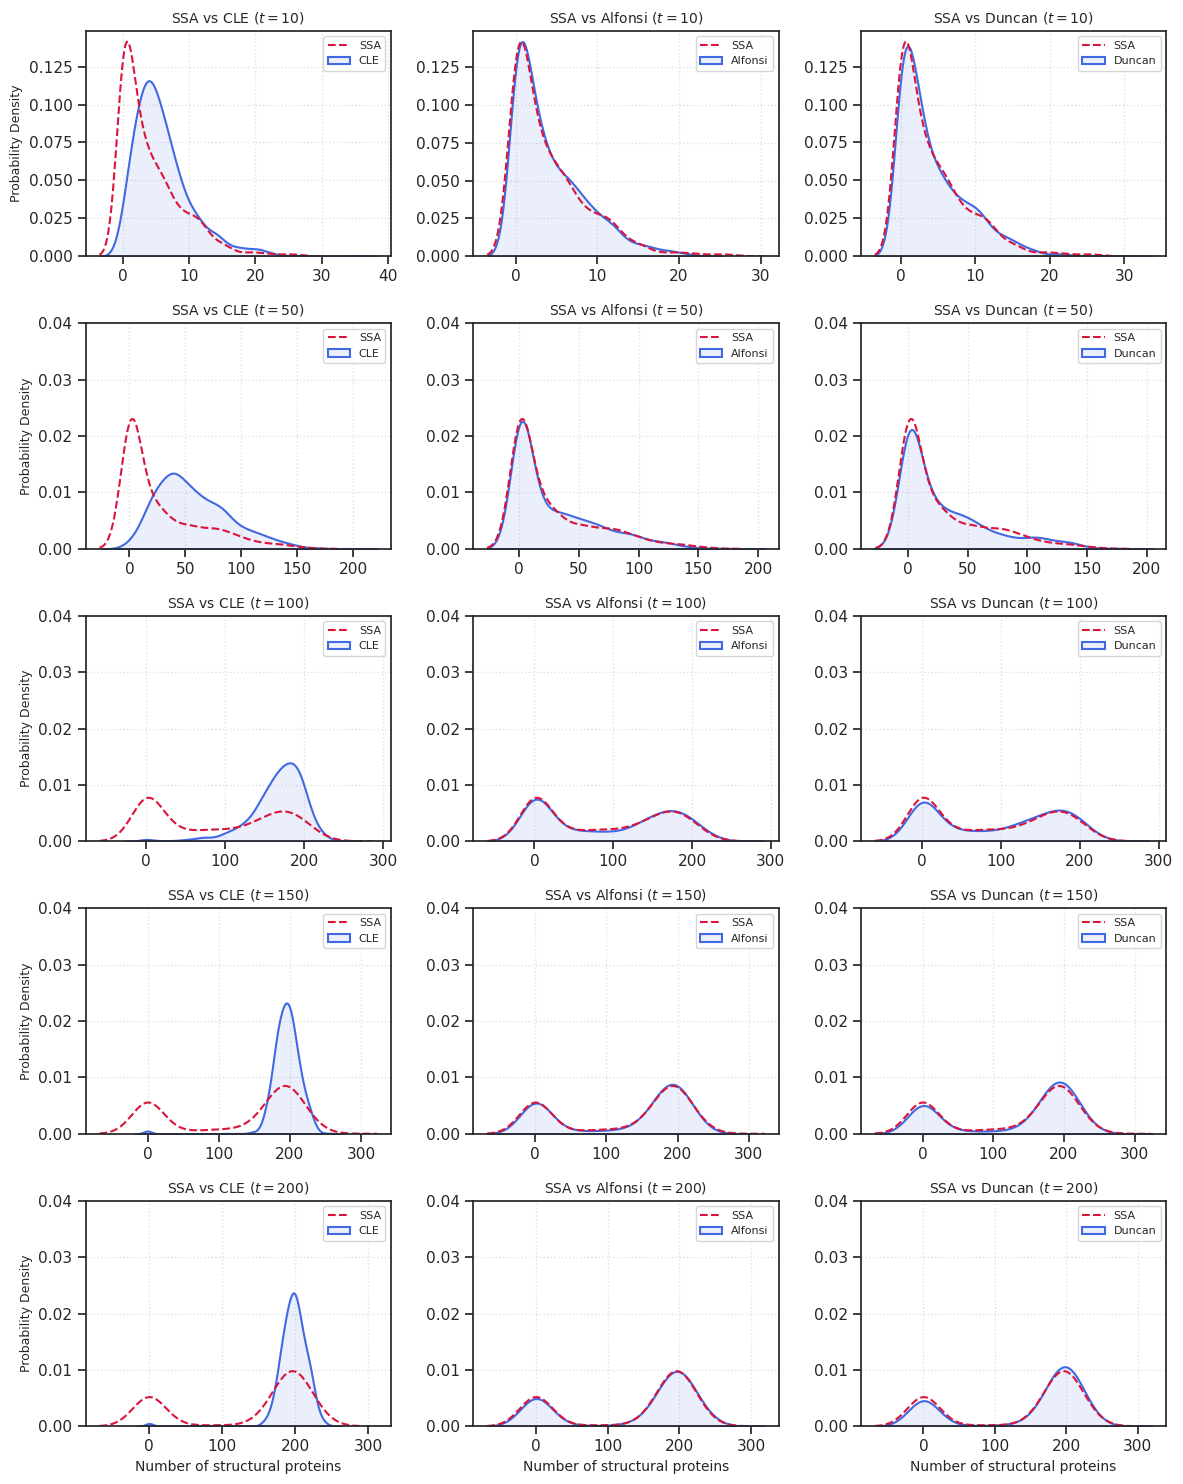

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

time_points = [10, 50, 100,150,200]
n_rows = len(time_points)


fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(12, 3 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(data_ssa[t][:,0],ax=ax_left, color="crimson", linestyle= "--",label="SSA",linewidth=1.5)
    sns.kdeplot(np.round(data_cle[t][:,0]),ax=ax_left,color="royalblue",label="CLE",linewidth=1.5,fill=True,alpha=0.1)
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,0], ax=ax_mid,color="crimson", linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(np.round(data_alfonsi[t][:,0]) ,ax=ax_mid, color="royalblue",label="Alfonsi",linewidth=1.5,fill=True, alpha=0.1)
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,0], color="crimson", ax=ax_right,linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(data_duncan_ssa[t][:,0], ax=ax_right, color = "royalblue",label="Duncan",linewidth=1.5,fill=True, alpha=0.1)
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10)

    ax_left.legend(loc="upper right", fontsize=8, frameon=True)
    ax_mid.legend(loc="upper right", fontsize=8, frameon=True)
    ax_right.legend(loc="upper right", fontsize=8, frameon=True)

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        
    if row_idx > 0:     
        ax_left.set_ylim([0,0.04])
        ax_mid.set_ylim([0,0.04])
        ax_right.set_ylim([0,0.04])
    ax_left.set_ylabel("Probability Density", fontsize=9)

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of structural proteins", fontsize=10)

plt.tight_layout()
plt.savefig("/work/scheibe5/bacteriophage_t7/probability_dist_structs.png")
plt.show()

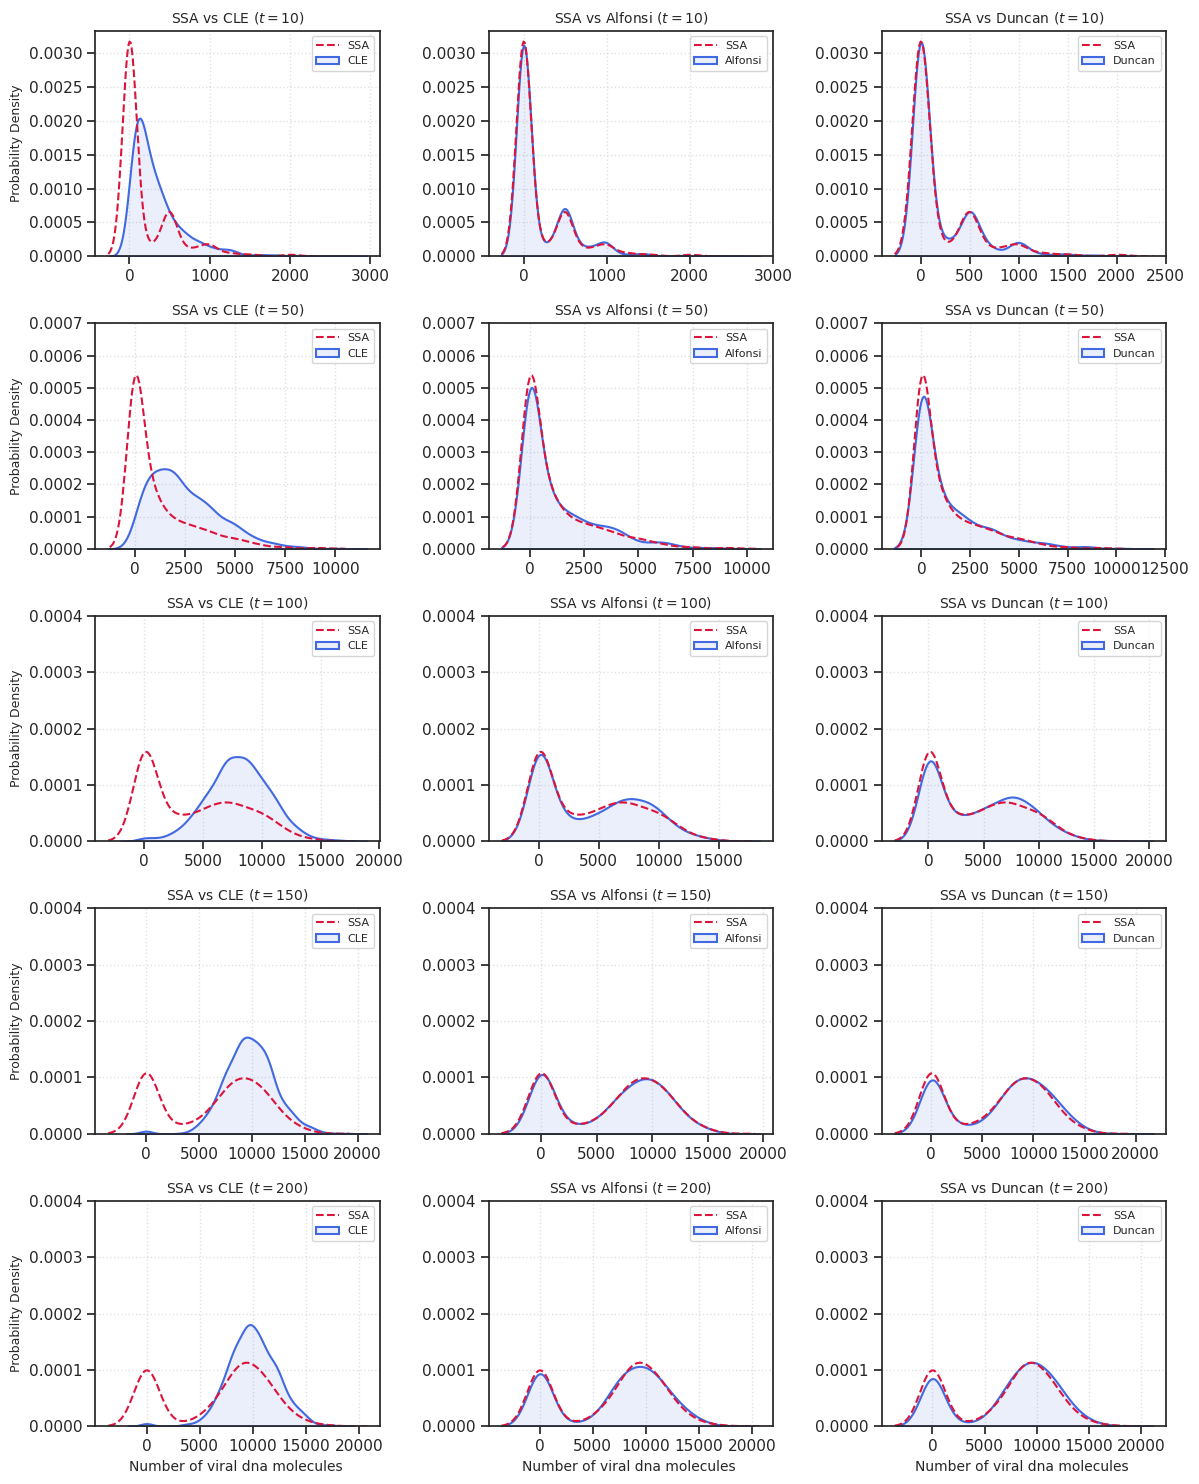

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

time_points = [10, 50, 100,150,200]
n_rows = len(time_points)


fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(12, 3 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(data_ssa[t][:,2],ax=ax_left, color="crimson", linestyle= "--",label="SSA",linewidth=1.5)
    sns.kdeplot(np.round(data_cle[t][:,2]),ax=ax_left,color="royalblue",label="CLE",linewidth=1.5,fill=True,alpha=0.1)
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,2], ax=ax_mid,color="crimson", linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(np.round(data_alfonsi[t][:,2]) ,ax=ax_mid, color="royalblue",label="Alfonsi",linewidth=1.5,fill=True, alpha=0.1)
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,2], color="crimson", ax=ax_right,linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(data_duncan_ssa[t][:,2], ax=ax_right, color = "royalblue",label="Duncan",linewidth=1.5,fill=True, alpha=0.1)
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10)

    ax_left.legend(loc="upper right", fontsize=8, frameon=True)
    ax_mid.legend(loc="upper right", fontsize=8, frameon=True)
    ax_right.legend(loc="upper right", fontsize=8, frameon=True)

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        
        
    if row_idx == 1:
        ax_left.set_ylim([0,0.0007])
        ax_mid.set_ylim([0,0.0007])
        ax_right.set_ylim([0,0.0007]) 
    elif row_idx > 1:     
        ax_left.set_ylim([0,0.0004])
        ax_mid.set_ylim([0,0.0004])
        ax_right.set_ylim([0,0.0004])
    ax_left.set_ylabel("Probability Density", fontsize=9)

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of viral dna molecules ", fontsize=10)

plt.tight_layout()
plt.savefig("/work/scheibe5/bacteriophage_t7/probability_dist_dna.png")
plt.show()

#### Lotka-Volterra

In [4]:
def fill_time_dict_gen(data, path,n_state, n_simulation, time_points):
    for current_result in stochastinetics.read_in_sim_results_gen(path,n_state):
        for j,ti in enumerate(time_points):
            idx = np.searchsorted(current_result[0], ti)
            idx = np.clip(idx, 1, len(current_result[1]) - 1)
            if abs(current_result[0][idx - 1] - ti) < abs(current_result[0][idx] - ti):
                idx -= 1
            data[ti].append(current_result[1][idx].copy())
    for _,ti in enumerate(time_points):
        data[ti] = np.array(data[ti])
    return data

path_cle = "/work/scheibe5/result_lotka_volterra_cle.csv"
path_duncan = "/work/scheibe5/result_lotka_volterra_duncan_15.0_25.0.csv"
path_alfonsi = "/work/scheibe5/result_lotka_volterra_gillespie_500.csv"
path_ssa= "/work/scheibe5/result_lotka_volterra_ssa.csv"

paths = [path_cle, path_duncan, path_alfonsi, path_ssa]
time_points = [1, 2, 3, 4, 5]

data_cle = {1: [], 2: [], 3: [],4: [],5:[]}
data_duncan = {1: [], 2: [], 3: [],4: [],5:[]}
data_alfonsi = {1: [], 2: [], 3: [],4: [],5:[]}
data_ssa = {1: [], 2: [], 3: [],4: [],5:[]}

datas = [data_cle, data_duncan, data_alfonsi, data_ssa]

for i,data in enumerate(datas):
    datas[i] = fill_time_dict_gen(data, paths[i],3,1000,time_points)

1 simulation runs have been streamed successfully.
2 simulation runs have been streamed successfully.
3 simulation runs have been streamed successfully.
4 simulation runs have been streamed successfully.
5 simulation runs have been streamed successfully.
6 simulation runs have been streamed successfully.
7 simulation runs have been streamed successfully.
8 simulation runs have been streamed successfully.
9 simulation runs have been streamed successfully.
10 simulation runs have been streamed successfully.
11 simulation runs have been streamed successfully.
12 simulation runs have been streamed successfully.
13 simulation runs have been streamed successfully.
14 simulation runs have been streamed successfully.
15 simulation runs have been streamed successfully.
16 simulation runs have been streamed successfully.
17 simulation runs have been streamed successfully.
18 simulation runs have been streamed successfully.
19 simulation runs have been streamed successfully.
20 simulation runs ha

In [7]:
data_cle, data_duncan_ssa, data_alfonsi, data_ssa = datas

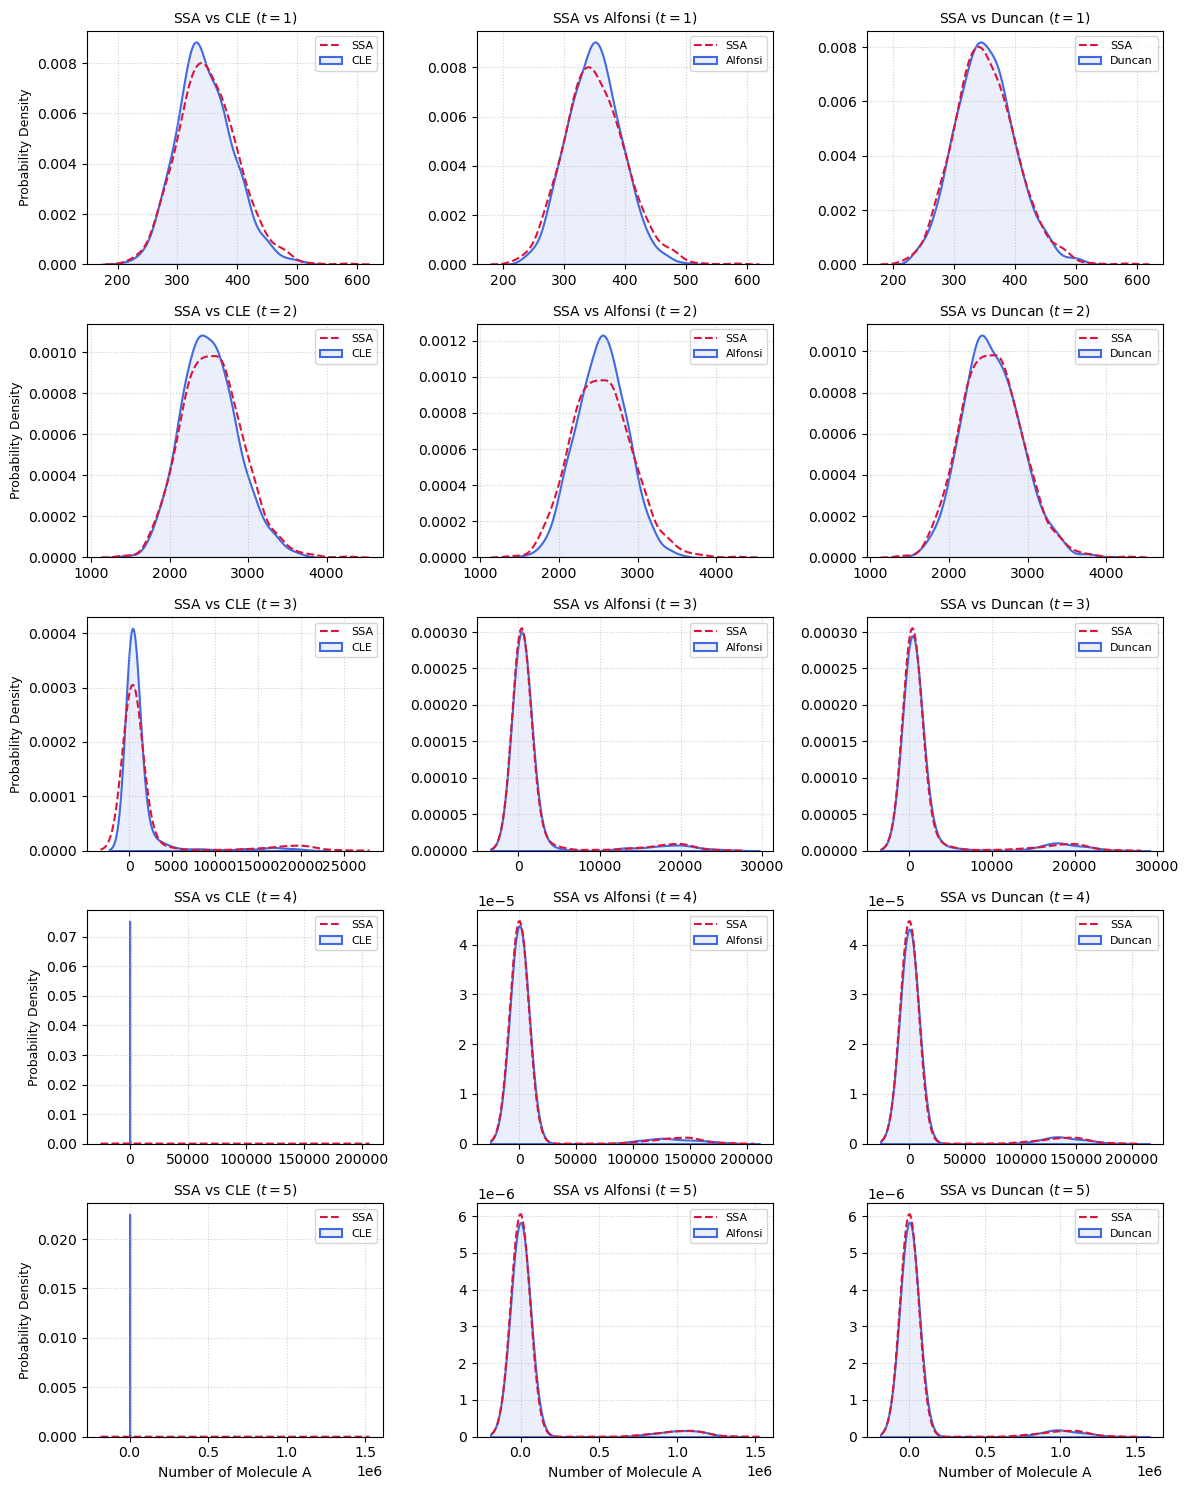

In [10]:
# Molecule - A
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

time_points = [1, 2, 3, 4, 5]
n_rows = len(time_points)


fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(12, 3 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(data_ssa[t][:,0],ax=ax_left, color="crimson", linestyle= "--",label="SSA",linewidth=1.5)
    sns.kdeplot(np.round(data_cle[t][:,0]),ax=ax_left,color="royalblue",label="CLE",linewidth=1.5,fill=True,alpha=0.1)
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,0], ax=ax_mid,color="crimson", linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(np.round(data_alfonsi[t][:,0]) ,ax=ax_mid, color="royalblue",label="Alfonsi",linewidth=1.5,fill=True, alpha=0.1)
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,0], color="crimson", ax=ax_right,linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(data_duncan_ssa[t][:,0], ax=ax_right, color = "royalblue",label="Duncan",linewidth=1.5,fill=True, alpha=0.1)
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10)

    ax_left.legend(loc="upper right", fontsize=8, frameon=True)
    ax_mid.legend(loc="upper right", fontsize=8, frameon=True)
    ax_right.legend(loc="upper right", fontsize=8, frameon=True)

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        
    # if row_idx > 0:     
    #     ax_left.set_ylim([0,0.4])
    #     ax_mid.set_ylim([0,0.4])
    #     ax_right.set_ylim([0,0.4])
    ax_left.set_ylabel("Probability Density", fontsize=9)

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of Molecule A", fontsize=10)

plt.tight_layout()
plt.savefig("/work/scheibe5/probability_dist_A.png")
plt.show()


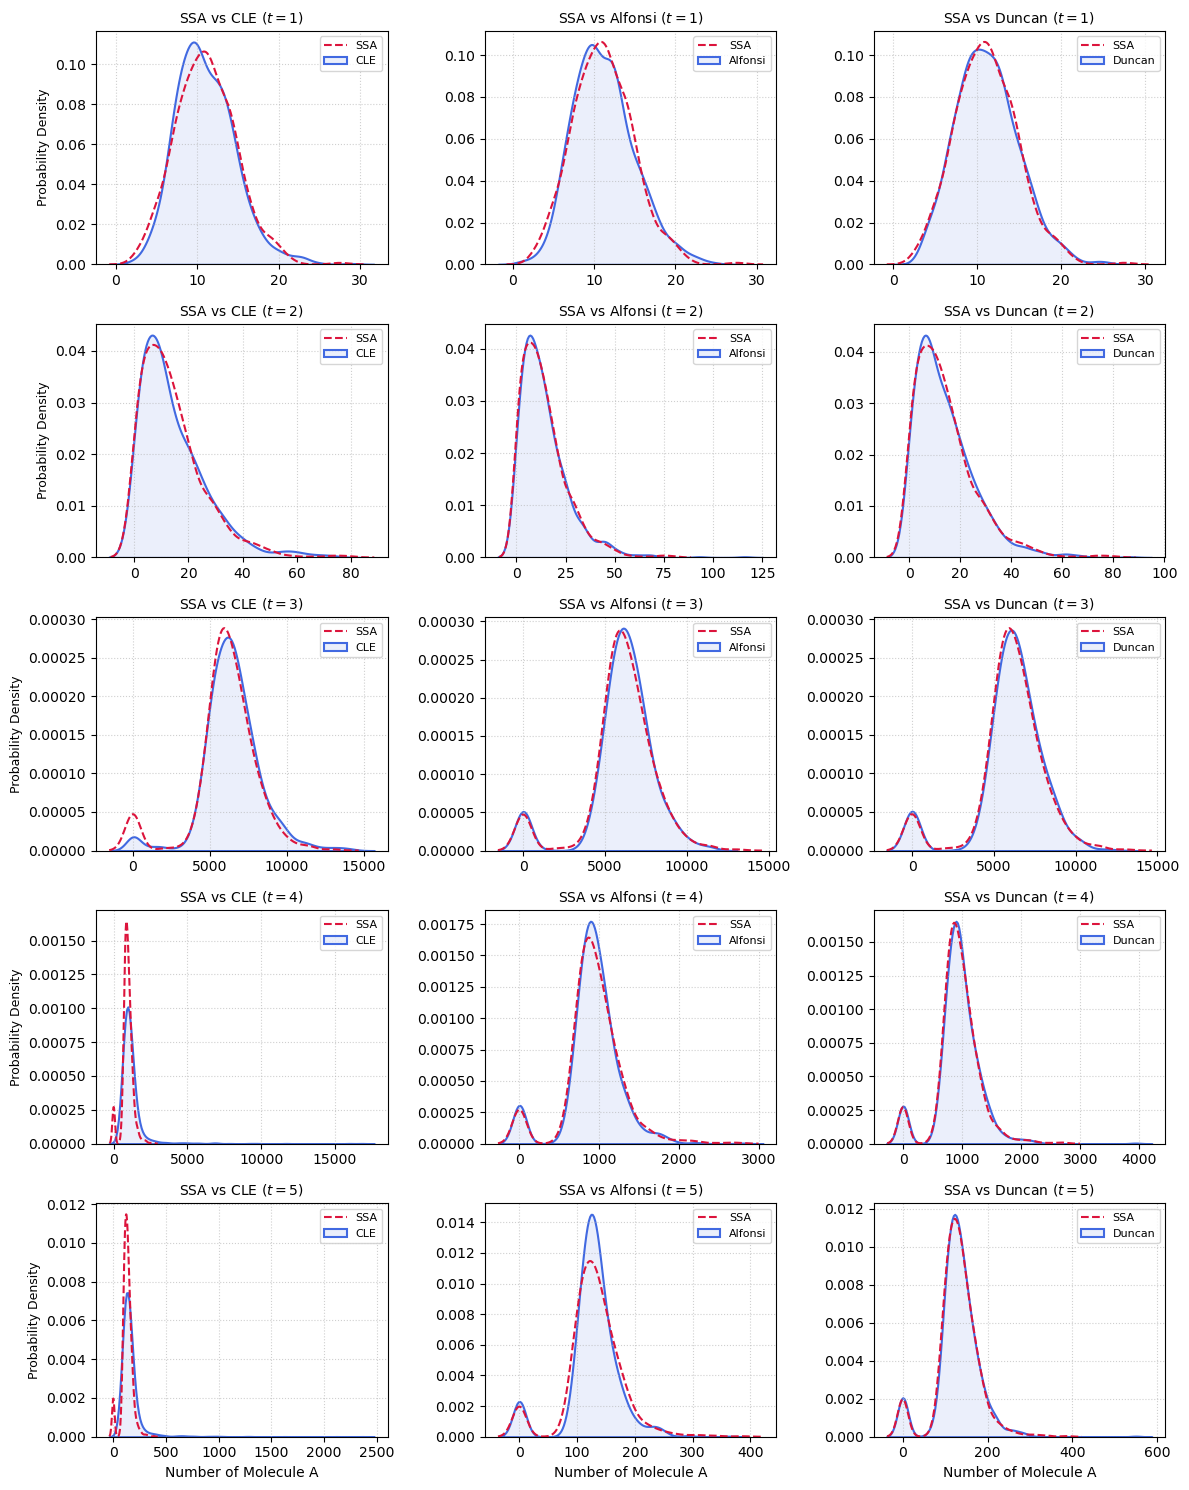

In [14]:
# Molecule - B
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

time_points = [1, 2, 3, 4, 5]
n_rows = len(time_points)


fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(12, 3 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(data_ssa[t][:,1],ax=ax_left, color="crimson", linestyle= "--",label="SSA",linewidth=1.5)
    sns.kdeplot(np.round(data_cle[t][:,1]),ax=ax_left,color="royalblue",label="CLE",linewidth=1.5,fill=True,alpha=0.1)
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,1], ax=ax_mid,color="crimson", linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(np.round(data_alfonsi[t][:,1]) ,ax=ax_mid, color="royalblue",label="Alfonsi",linewidth=1.5,fill=True, alpha=0.1)
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10)

    sns.kdeplot(data_ssa[t][:,1], color="crimson", ax=ax_right,linestyle="--",label="SSA", linewidth=1.5)
    sns.kdeplot(data_duncan_ssa[t][:,1], ax=ax_right, color = "royalblue",label="Duncan",linewidth=1.5,fill=True, alpha=0.1)
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10)

    ax_left.legend(loc="upper right", fontsize=8, frameon=True)
    ax_mid.legend(loc="upper right", fontsize=8, frameon=True)
    ax_right.legend(loc="upper right", fontsize=8, frameon=True)

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylabel("")
        ax.set_xlabel("")
        
    # if row_idx > 0:     
    #     ax_left.set_ylim([0,0.4])
    #     ax_mid.set_ylim([0,0.4])
    #     ax_right.set_ylim([0,0.4])
    ax_left.set_ylabel("Probability Density", fontsize=9)

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of Molecule A", fontsize=10)

plt.tight_layout()
plt.savefig("/work/scheibe5/probability_dist_B.png")
plt.show()


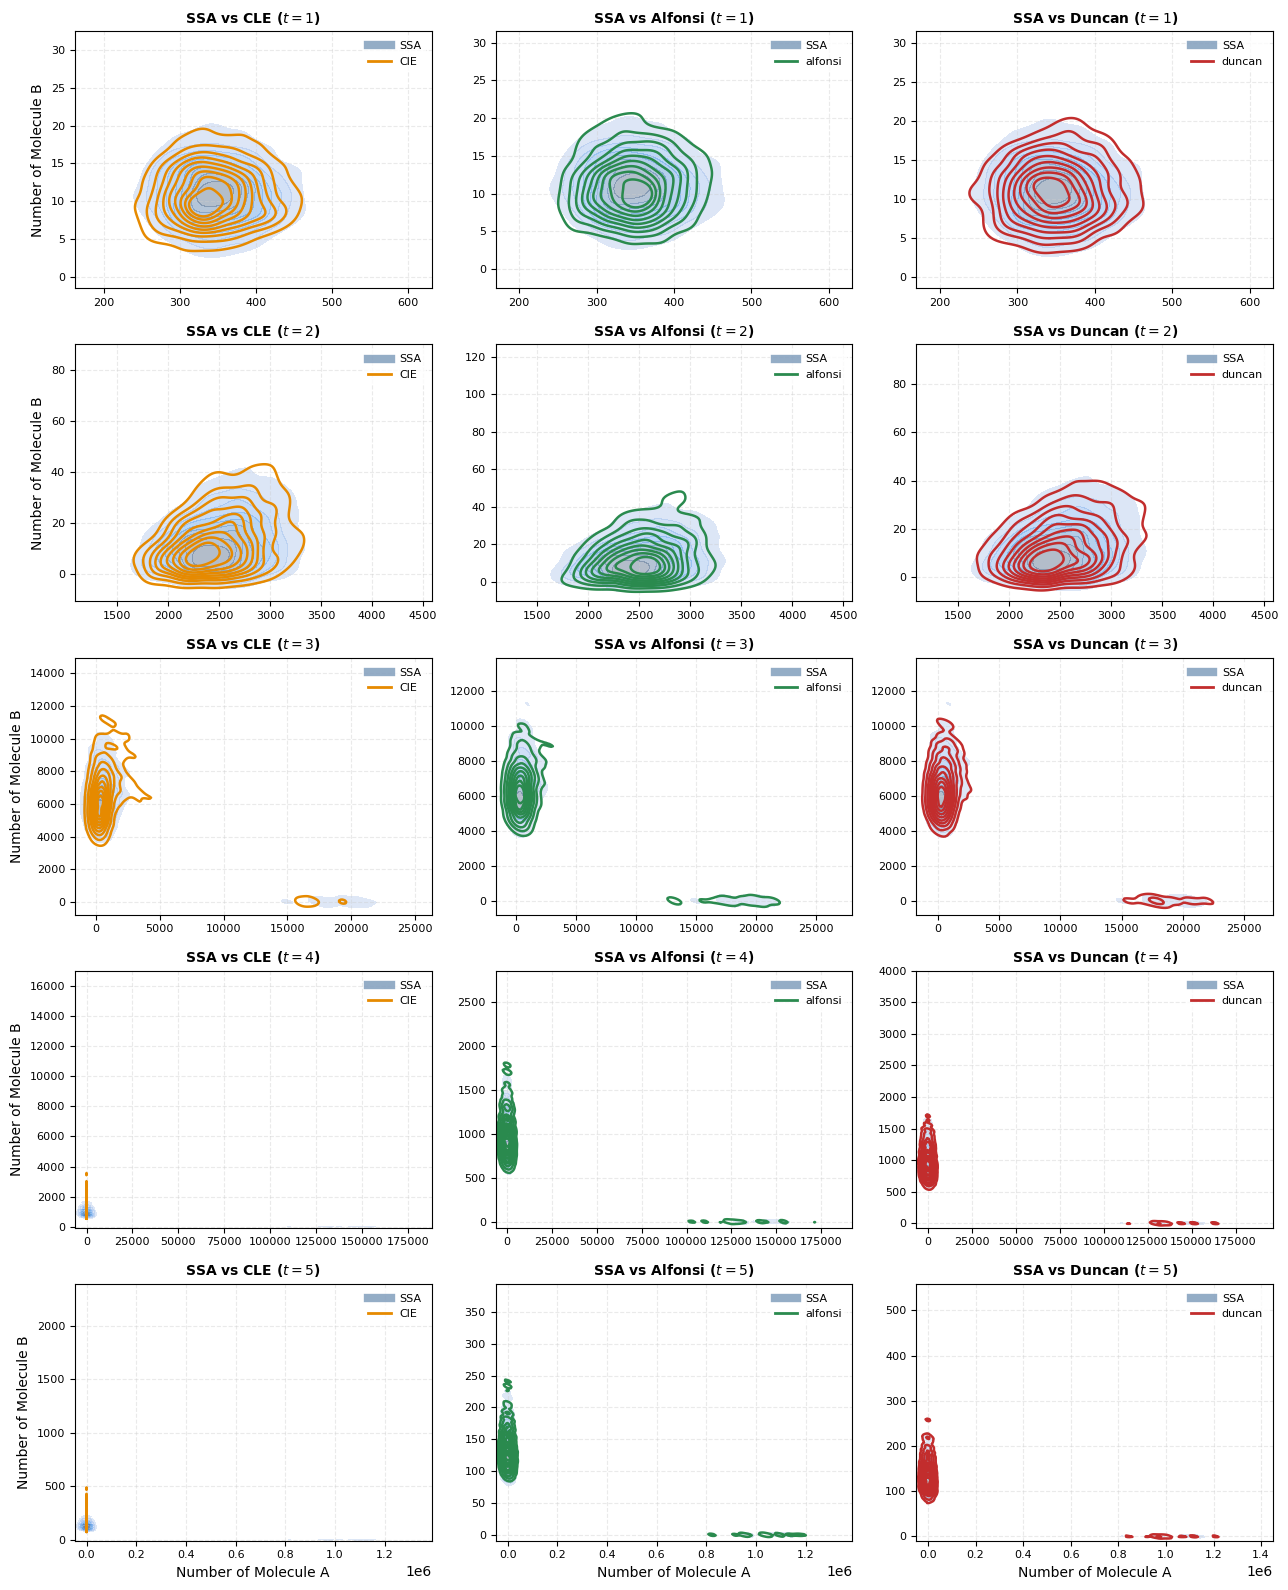

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D

time_points = [1, 2, 3, 4, 5]
n_rows = len(time_points)

c_ssa = "#2b5c8f"      
c_cle = "#e68a00"      
c_alfonsi = "#2a8a4e"  
c_duncan = "#c22d2d"

smoothings= [1, 0.9,0.4,0.2,0.2]

fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(13, 3.2 * n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, t in enumerate(time_points):
    ax_left = axes[row_idx, 0]
    ax_mid = axes[row_idx, 1]
    ax_right = axes[row_idx, 2]

    sns.kdeplot(x=data_ssa[t][:,0], y=data_ssa[t][:,1], ax=ax_left, fill=True, alpha=0.4, color=c_ssa, thresh=0.1, bw_adjust=smoothings[row_idx])
    sns.kdeplot(x=np.round(data_cle[t][:,0]), y=np.round(data_cle[t][:,1]), ax=ax_left, fill=False, color=c_cle, thresh=0.1, linewidths=1.8, bw_adjust=smoothings[row_idx])
    ax_left.set_title(f"SSA vs CLE ($t = {t}$)", fontsize=10, fontweight="semibold")

    legend_elements_left = [
        Line2D([0], [0], color=c_ssa, lw=6, alpha=0.5, label="SSA"),
        Line2D([0], [0], color=c_cle, lw=2, label="ClE")
    ]
    ax_left.legend(handles=legend_elements_left, loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="none")

    sns.kdeplot(x=data_ssa[t][:,0], y=data_ssa[t][:,1], ax=ax_mid, fill=True, alpha=0.4, color=c_ssa, thresh=0.1, bw_adjust=smoothings[row_idx])
    sns.kdeplot(x=np.round(data_alfonsi[t][:,0]), y=np.round(data_alfonsi[t][:,1]), ax=ax_mid, fill=False, color=c_alfonsi, thresh=0.1, linewidths=1.8, bw_adjust=smoothings[row_idx])
    ax_mid.set_title(f"SSA vs Alfonsi ($t = {t}$)", fontsize=10, fontweight="semibold")

    legend_elements_mid = [
        Line2D([0], [0], color=c_ssa, lw=6, alpha=0.5, label="SSA"),
        Line2D([0], [0], color=c_alfonsi, lw=2, label="alfonsi")
    ]
    ax_mid.legend(handles=legend_elements_mid, loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="none")

    sns.kdeplot(x=data_ssa[t][:,0], y=data_ssa[t][:,1], ax=ax_right, fill=True, alpha=0.4, color=c_ssa, thresh=0.1, bw_adjust=smoothings[row_idx])
    sns.kdeplot(x=data_duncan_ssa[t][:,0], y=data_duncan_ssa[t][:,1], ax=ax_right, fill=False, color=c_duncan, thresh=0.1, linewidths=1.8, bw_adjust=smoothings[row_idx])
    ax_right.set_title(f"SSA vs Duncan ($t = {t}$)", fontsize=10, fontweight="semibold")

    legend_elements_right = [
        Line2D([0], [0], color=c_ssa, lw=6, alpha=0.5, label="SSA"),
        Line2D([0], [0], color=c_duncan, lw=2, label="duncan")
    ]
    ax_right.legend(handles=legend_elements_right, loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="none")

    for ax in [ax_left, ax_mid, ax_right]:
        ax.grid(True, linestyle="--", alpha=0.4, color="#cccccc")
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(labelsize=8)
        
    ax_left.set_ylabel("Number of Molecule B", fontsize=10, fontweight="medium")

for col_idx in range(3):
    axes[-1, col_idx].set_xlabel("Number of Molecule A", fontsize=10, fontweight="medium")

plt.tight_layout()
plt.savefig("/work/scheibe5/probability_dist_B.png", dpi=300)
plt.show()